<a href="https://colab.research.google.com/github/contactvarun2002/Web-Mining-2/blob/main/Web_Mining_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PROCESS 1 - PREPROCESSING
Input file: /content/drive/MyDrive/Web mining files/online_classroom_data.csv

Raw dataset shape: (71, 16)

Columns:
['Unnamed: 0', 'total_posts', 'helpful_post', 'nice_code_post', 'collaborative_post', 'confused_post', 'creative_post', 'bad_post', 'amazing_post', 'timeonline', 'sk1_classroom', 'sk2_classroom', 'sk5_classroom', 'sk3_classroom', 'sk4_classroom', 'Approved']


,Unnamed: 0,total_posts,helpful_post,nice_code_post,collaborative_post,confused_post,creative_post,bad_post,amazing_post,timeonline,sk1_classroom,sk2_classroom,sk5_classroom,sk3_classroom,sk4_classroom,Approved
0,0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,1.0,1600.0,"2,1","2,4","3,5","3,6","1,7",0
1,1,1.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,592.0,"0,3","0,3",0,"0,1","0,2",0
2,2,2.0,4.0,3.0,9.0,0.0,16.0,1.0,8.0,1110.0,8,5,5,7,5,1
3,3,5.0,1.0,3.0,9.0,2.0,11.0,0.0,8.0,8651.0,6,5,4,6,4,1
4,4,14.0,6.0,15.0,28.0,0.0,50.0,0.0,45.0,34172.0,"8,7",9,"6,5",10,"8,8",1



Duplicate rows removed: 8

PREPROCESSING RESULT
Learners : 63
Features : 21
Target   : Approved

Target distribution:
Approved
1    50
0    13
Name: count, dtype: int64

Saved: /content/drive/MyDrive/Preprocessed_Behavioral_Features.csv


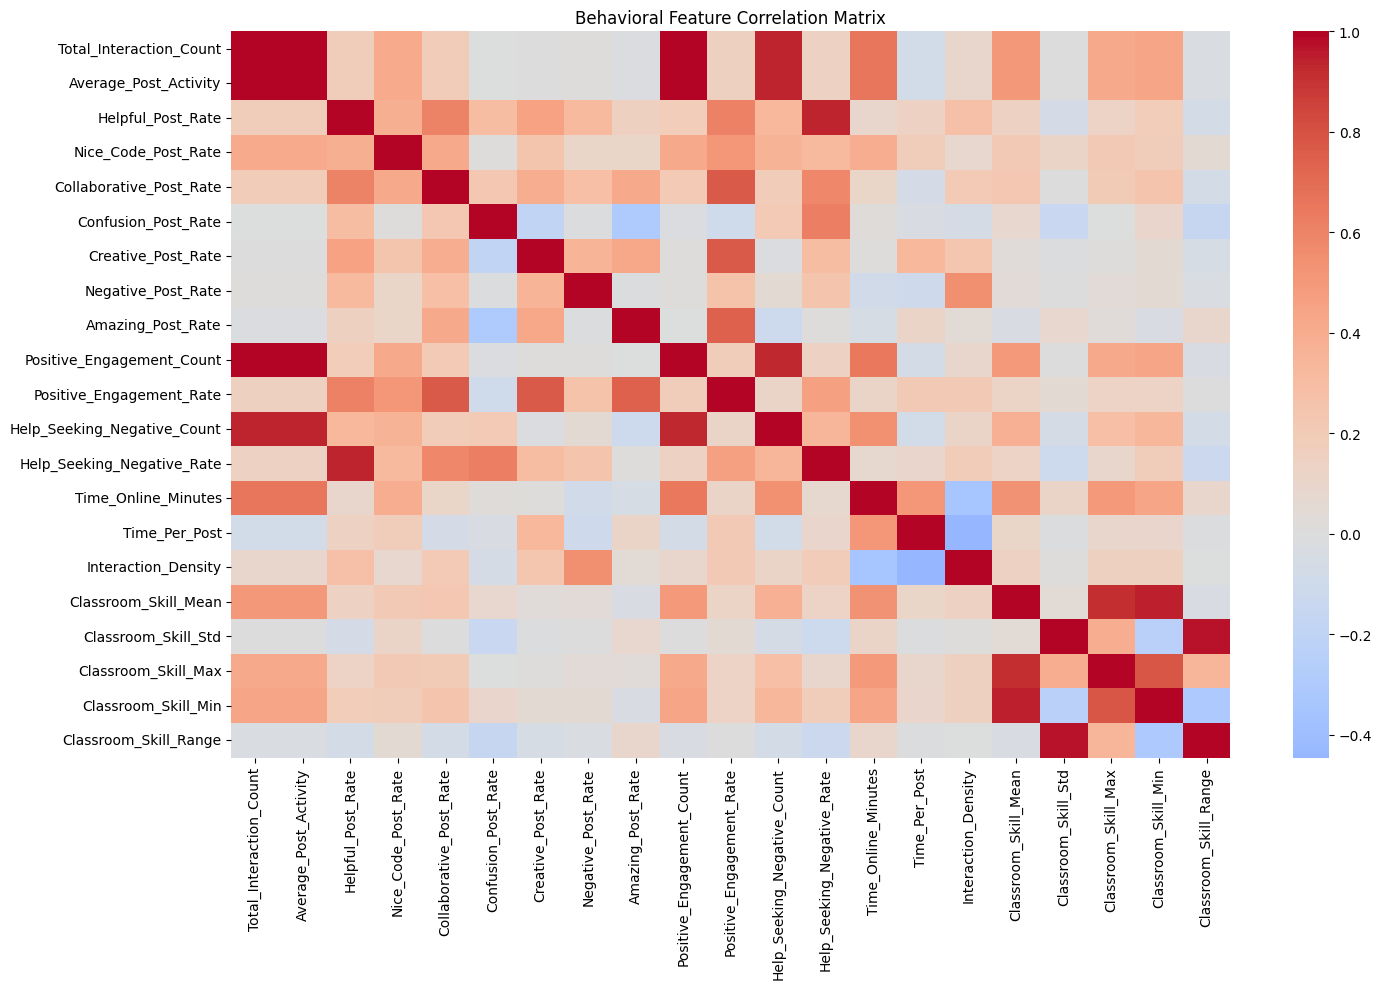


PROCESS 1 COMPLETED.


In [ ]:
# ================================================================
# PROCESS 1
# PREPROCESSING + BEHAVIORAL FEATURE CONSTRUCTION
# ================================================================

!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print("=" * 70)
print("PROCESS 1 - PREPROCESSING")
print("=" * 70)


# ================================================================
# 1. LOAD DATA
# ================================================================

possible_paths = [
    "/content/drive/MyDrive/Web mining files/online_classroom_data.csv",
]

INPUT_FILE = None

for path in possible_paths:
    if os.path.exists(path):
        INPUT_FILE = path
        break

if INPUT_FILE is None:

    from google.colab import files

    print("Upload online_classroom_data.csv")

    uploaded = files.upload()

    csv_files = [
        f for f in uploaded.keys()
        if f.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file was uploaded."
        )

    INPUT_FILE = "/content/" + csv_files[0]


print("Input file:", INPUT_FILE)


# ================================================================
# 2. READ DATA
# ================================================================

df_raw = pd.read_csv(INPUT_FILE)

print("\nRaw dataset shape:", df_raw.shape)

print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head())


# ================================================================
# 3. REMOVE UNNECESSARY COLUMNS
# ================================================================

index_like_columns = [
    col
    for col in df_raw.columns
    if str(col).lower().startswith("unnamed")
]

df = df_raw.drop(
    columns=index_like_columns,
    errors="ignore"
).copy()


# ================================================================
# 4. REMOVE DUPLICATES
# ================================================================

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print(
    "\nDuplicate rows removed:",
    before - after
)


# ================================================================
# 5. NUMERIC COLUMNS
# ================================================================

numeric_columns = [
    "total_posts",
    "helpful_post",
    "nice_code_post",
    "collaborative_post",
    "confused_post",
    "creative_post",
    "bad_post",
    "amazing_post",
    "timeonline",
    "Approved"
]

for col in numeric_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ================================================================
# 6. CLASSROOM SKILL PARSING
# ================================================================

skill_columns = [
    "sk1_classroom",
    "sk2_classroom",
    "sk5_classroom",
    "sk3_classroom",
    "sk4_classroom"
]


def parse_skill_value(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "":
        return np.nan

    try:
        return float(value)

    except:

        parts = re.findall(
            r"-?\d+(?:\.\d+)?",
            value
        )

        if len(parts) == 0:
            return np.nan

        numbers = [
            float(x)
            for x in parts
        ]

        return np.mean(numbers)


for col in skill_columns:

    if col in df.columns:

        df[col + "_Numeric"] = (
            df[col].apply(
                parse_skill_value
            )
        )


# ================================================================
# 7. INVALID VALUE HANDLING
# ================================================================

behavior_raw_columns = [
    "total_posts",
    "helpful_post",
    "nice_code_post",
    "collaborative_post",
    "confused_post",
    "creative_post",
    "bad_post",
    "amazing_post",
    "timeonline"
]

for col in behavior_raw_columns:

    if col in df.columns:

        df.loc[
            df[col] < 0,
            col
        ] = np.nan


# ================================================================
# 8. MISSING VALUE IMPUTATION
# ================================================================

for col in df.select_dtypes(
    include=np.number
).columns:

    if col == "Approved":
        continue

    median_value = df[col].median()

    if pd.isna(median_value):
        median_value = 0

    df[col] = df[col].fillna(
        median_value
    )


# ================================================================
# 9. BEHAVIORAL FEATURE CONSTRUCTION
# ================================================================

posts = df["total_posts"].replace(
    0,
    np.nan
)


df["Total_Interaction_Count"] = (
    df[
        [
            "total_posts",
            "helpful_post",
            "nice_code_post",
            "collaborative_post",
            "confused_post",
            "creative_post",
            "bad_post",
            "amazing_post"
        ]
    ].sum(axis=1)
)


df["Average_Post_Activity"] = (
    df["Total_Interaction_Count"] / 7
)


df["Helpful_Post_Rate"] = (
    df["helpful_post"] / posts
)

df["Nice_Code_Post_Rate"] = (
    df["nice_code_post"] / posts
)

df["Collaborative_Post_Rate"] = (
    df["collaborative_post"] / posts
)

df["Confusion_Post_Rate"] = (
    df["confused_post"] / posts
)

df["Creative_Post_Rate"] = (
    df["creative_post"] / posts
)

df["Negative_Post_Rate"] = (
    df["bad_post"] / posts
)

df["Amazing_Post_Rate"] = (
    df["amazing_post"] / posts
)


df["Positive_Engagement_Count"] = (
    df["helpful_post"]
    + df["nice_code_post"]
    + df["collaborative_post"]
    + df["creative_post"]
    + df["amazing_post"]
)


df["Positive_Engagement_Rate"] = (
    df["Positive_Engagement_Count"] / posts
)


df["Help_Seeking_Negative_Count"] = (
    df["helpful_post"]
    + df["confused_post"]
)


df["Help_Seeking_Negative_Rate"] = (
    df["Help_Seeking_Negative_Count"] / posts
)


df["Time_Online_Minutes"] = (
    df["timeonline"]
)


df["Time_Per_Post"] = (
    df["timeonline"] / posts
)


df["Interaction_Density"] = (
    df["Total_Interaction_Count"]
    / (df["timeonline"] + 1)
)


# ================================================================
# 10. CLASSROOM SKILL FEATURES
# ================================================================

numeric_skill_columns = [
    col + "_Numeric"
    for col in skill_columns
    if col in df.columns
]


df["Classroom_Skill_Mean"] = (
    df[numeric_skill_columns].mean(axis=1)
)

df["Classroom_Skill_Std"] = (
    df[numeric_skill_columns].std(axis=1)
)

df["Classroom_Skill_Max"] = (
    df[numeric_skill_columns].max(axis=1)
)

df["Classroom_Skill_Min"] = (
    df[numeric_skill_columns].min(axis=1)
)

df["Classroom_Skill_Range"] = (
    df["Classroom_Skill_Max"]
    - df["Classroom_Skill_Min"]
)


# ================================================================
# 11. CLEAN INFINITY / MISSING VALUES
# ================================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)


for col in df.select_dtypes(
    include=np.number
).columns:

    if col == "Approved":
        continue

    df[col] = df[col].fillna(
        df[col].median()
    )


# ================================================================
# 12. BEHAVIORAL FEATURE LIST
# ================================================================

behavioral_features = [

    "Total_Interaction_Count",
    "Average_Post_Activity",

    "Helpful_Post_Rate",
    "Nice_Code_Post_Rate",
    "Collaborative_Post_Rate",
    "Confusion_Post_Rate",
    "Creative_Post_Rate",
    "Negative_Post_Rate",
    "Amazing_Post_Rate",

    "Positive_Engagement_Count",
    "Positive_Engagement_Rate",

    "Help_Seeking_Negative_Count",
    "Help_Seeking_Negative_Rate",

    "Time_Online_Minutes",
    "Time_Per_Post",
    "Interaction_Density",

    "Classroom_Skill_Mean",
    "Classroom_Skill_Std",
    "Classroom_Skill_Max",
    "Classroom_Skill_Min",
    "Classroom_Skill_Range"
]


behavioral_features = [
    f
    for f in behavioral_features
    if f in df.columns
]


# ================================================================
# 13. INPUT / TARGET
# ================================================================

X_behavior = df[
    behavioral_features
].copy()

y = df["Approved"].astype(int)


print("\n" + "=" * 70)
print("PREPROCESSING RESULT")
print("=" * 70)

print("Learners :", len(df))
print("Features :", X_behavior.shape[1])
print("Target   :", "Approved")

print("\nTarget distribution:")
print(y.value_counts())


# ================================================================
# 14. SAVE PREPROCESSED DATA
# ================================================================

PREPROCESSED_FILE = (
    "/content/drive/MyDrive/"
    "Preprocessed_Behavioral_Features.csv"
)

df.to_csv(
    PREPROCESSED_FILE,
    index=False
)

print(
    "\nSaved:",
    PREPROCESSED_FILE
)


# ================================================================
# 15. CORRELATION VISUALIZATION
# ================================================================

plt.figure(figsize=(15, 10))

sns.heatmap(
    X_behavior.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Behavioral Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()


print("\nPROCESS 1 COMPLETED.")

PROCESS 1 - PREPROCESSING RESULTS


,Parameter,Value
0,Original Dataset Rows,71
1,Original Dataset Columns,16
2,Processed Dataset Rows,63
3,Processed Dataset Columns,41
4,Behavioral Features,21
5,Target Variable,Approved
6,Missing Values After Processing,0
7,Duplicate Rows After Processing,0


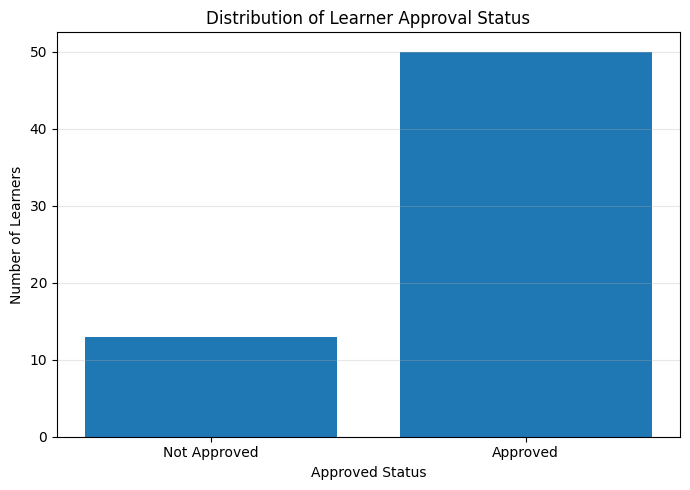

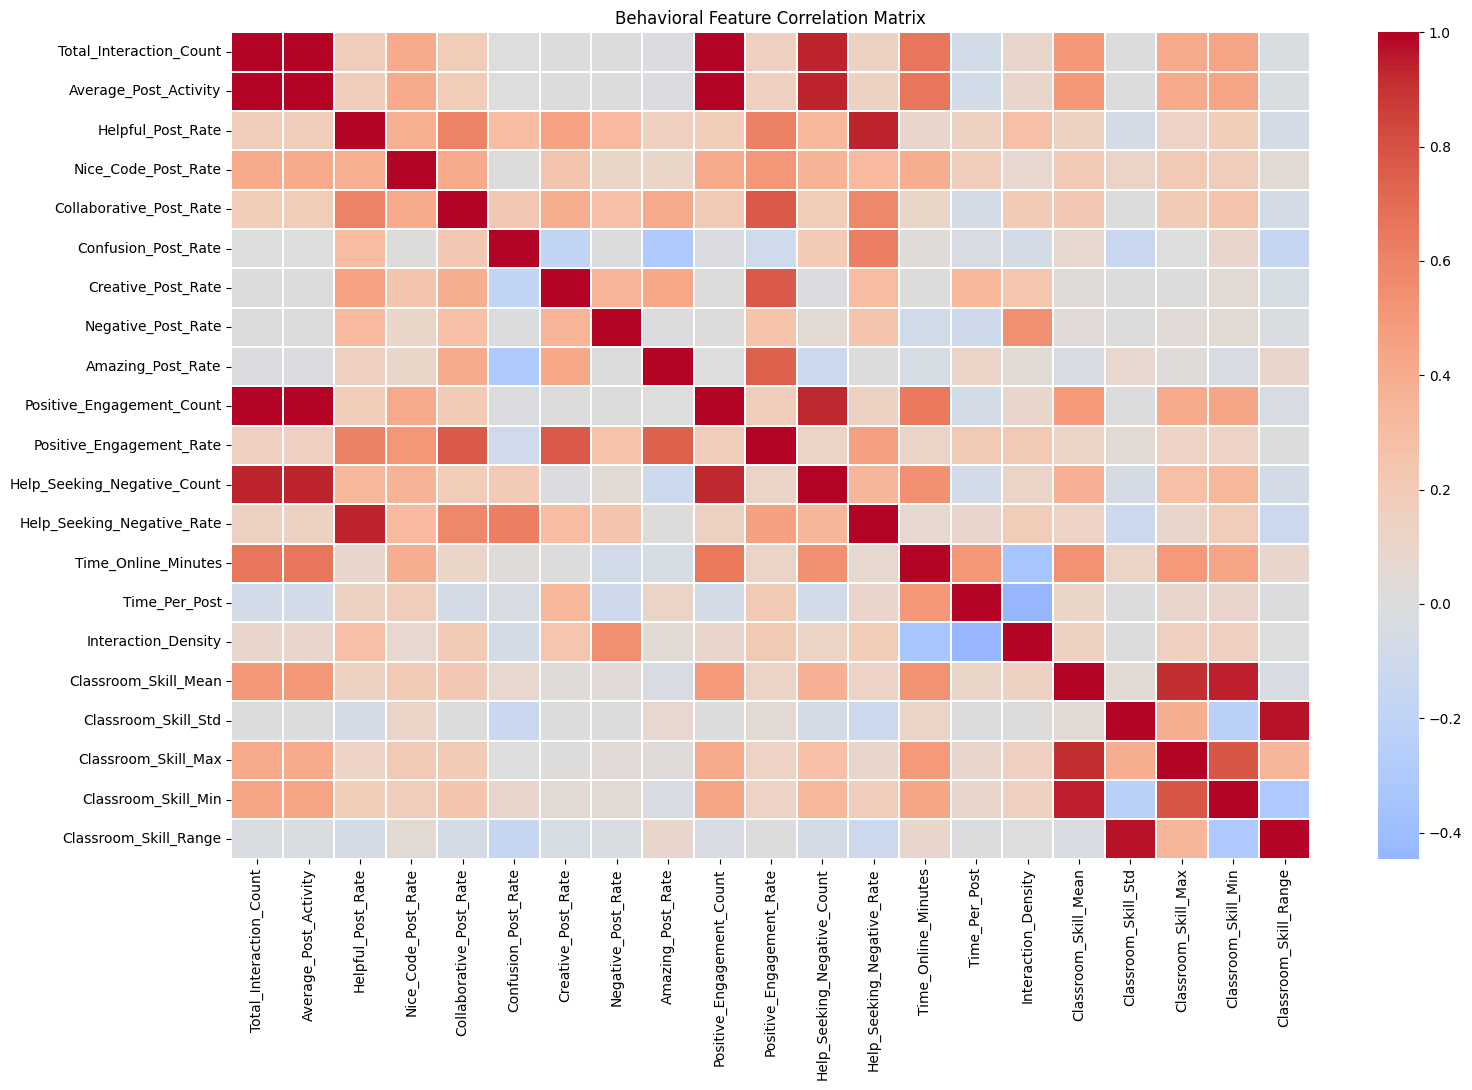

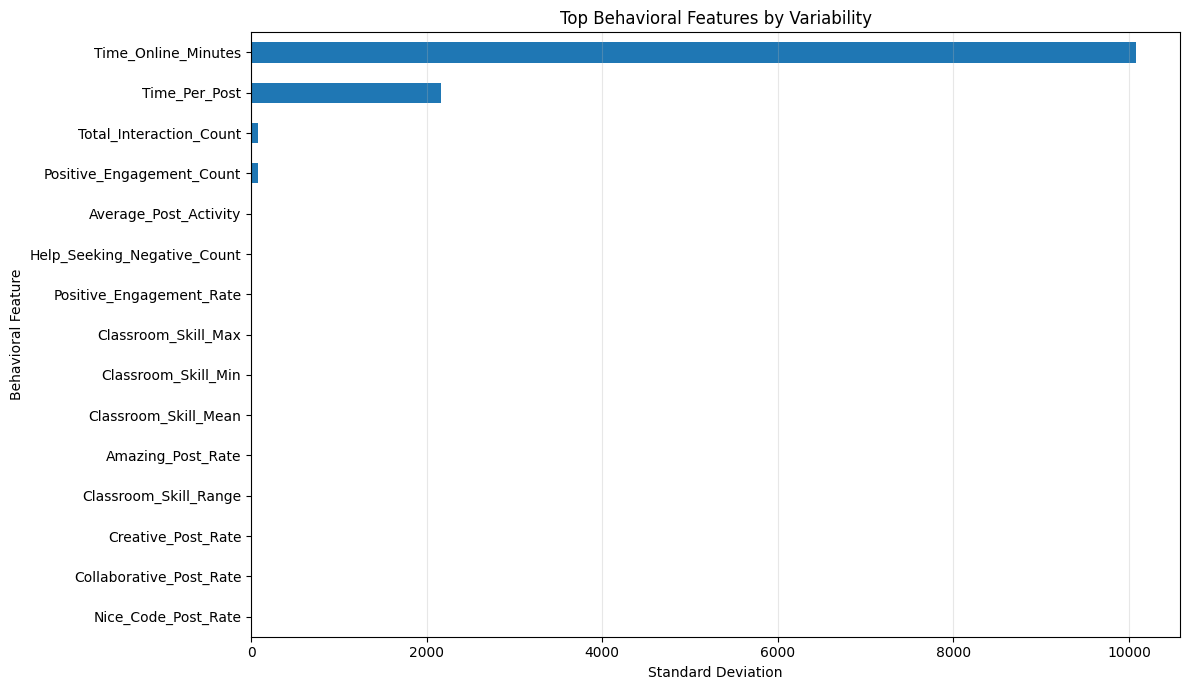

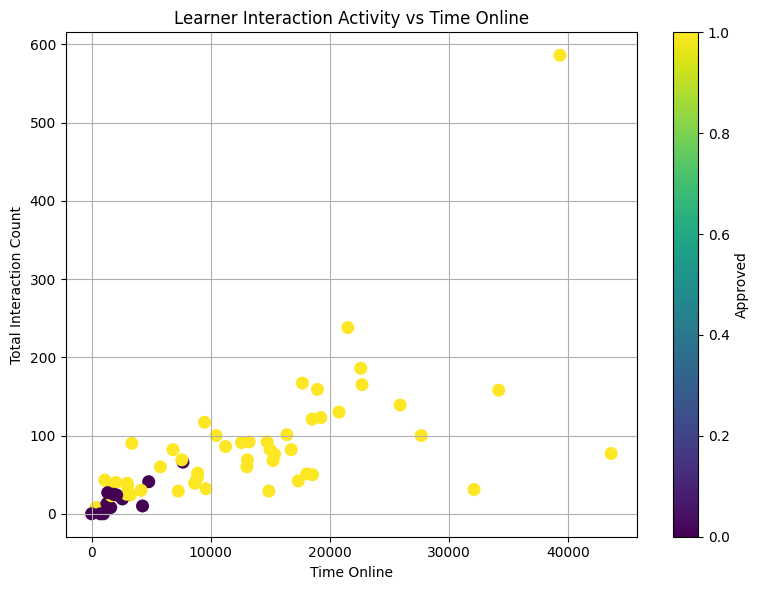

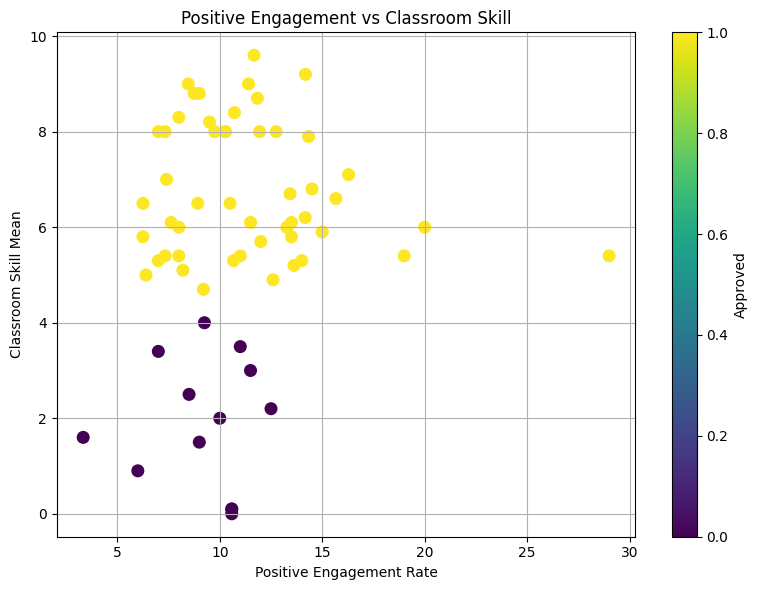

,count,mean,std,min,25%,50%,75%,max
Total_Interaction_Count,63.0,74.666667,83.080218,0.000000,29.000000,52.000000,92.000000,586.000000
Average_Post_Activity,63.0,10.666667,11.868603,0.000000,4.142857,7.428571,13.142857,83.714286
Helpful_Post_Rate,63.0,0.687318,0.529838,0.000000,0.267857,0.641026,1.000000,2.500000
Nice_Code_Post_Rate,63.0,1.080836,0.841351,0.000000,0.416667,1.000000,1.718182,3.545455
Collaborative_Post_Rate,63.0,1.988293,1.062294,0.000000,1.100000,1.934058,2.500000,5.000000
Confusion_Post_Rate,63.0,0.095927,0.239143,0.000000,0.000000,0.000000,0.000000,1.000000
Creative_Post_Rate,63.0,3.520382,1.432581,0.666667,2.557692,3.416667,4.156566,8.000000
Negative_Post_Rate,63.0,0.011684,0.065914,0.000000,0.000000,0.000000,0.000000,0.500000
Amazing_Post_Rate,63.0,3.687675,1.691412,1.000000,2.522727,3.583333,4.183333,13.000000
Positive_Engagement_Count,63.0,67.777778,76.227894,0.000000,25.000000,48.000000,83.500000,537.000000



PROCESS 1 RESULT COMPLETED.


In [ ]:
# ================================================================
# PROCESS 1 - RESULTS AND VISUALIZATIONS
# PREPROCESSING + BEHAVIORAL FEATURE CONSTRUCTION
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("PROCESS 1 - PREPROCESSING RESULTS")
print("=" * 70)


# ================================================================
# RESULT 1 - DATASET INFORMATION
# ================================================================

preprocessing_results = pd.DataFrame({

    "Parameter": [

        "Original Dataset Rows",
        "Original Dataset Columns",
        "Processed Dataset Rows",
        "Processed Dataset Columns",
        "Behavioral Features",
        "Target Variable",
        "Missing Values After Processing",
        "Duplicate Rows After Processing"
    ],

    "Value": [

        df_raw.shape[0],
        df_raw.shape[1],
        df.shape[0],
        df.shape[1],
        len(behavioral_features),
        "Approved",
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum())
    ]
})


display(preprocessing_results)


# ================================================================
# VISUALIZATION 1
# TARGET DISTRIBUTION
# ================================================================

plt.figure(figsize=(7, 5))

target_counts = y.value_counts().sort_index()

labels = [
    "Not Approved",
    "Approved"
]

plt.bar(
    labels,
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.xlabel("Approved Status")
plt.ylabel("Number of Learners")
plt.title(
    "Distribution of Learner Approval Status"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 2
# BEHAVIORAL FEATURE CORRELATION
# ================================================================

plt.figure(figsize=(16, 11))

sns.heatmap(
    X_behavior.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Behavioral Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 3
# BEHAVIORAL FEATURE VARIABILITY
# ================================================================

feature_std = (
    X_behavior.std()
    .sort_values(
        ascending=False
    )
)


plt.figure(figsize=(12, 7))

feature_std.head(15).sort_values().plot(
    kind="barh"
)

plt.xlabel(
    "Standard Deviation"
)

plt.ylabel(
    "Behavioral Feature"
)

plt.title(
    "Top Behavioral Features by Variability"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 4
# TOTAL INTERACTION VS TIME ONLINE
# ================================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["timeonline"],
    df["Total_Interaction_Count"],
    c=y,
    cmap="viridis",
    s=70
)

plt.xlabel(
    "Time Online"
)

plt.ylabel(
    "Total Interaction Count"
)

plt.title(
    "Learner Interaction Activity vs Time Online"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 5
# POSITIVE ENGAGEMENT
# ================================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Positive_Engagement_Rate"],
    df["Classroom_Skill_Mean"],
    c=y,
    cmap="viridis",
    s=70
)

plt.xlabel(
    "Positive Engagement Rate"
)

plt.ylabel(
    "Classroom Skill Mean"
)

plt.title(
    "Positive Engagement vs Classroom Skill"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# RESULT 2 - FEATURE STATISTICS
# ================================================================

feature_statistics = (
    X_behavior.describe()
    .T
)

display(
    feature_statistics
)


print("\nPROCESS 1 RESULT COMPLETED.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.5 MB/s eta 0:00:00
PROCESS 2 - FEATURE EXTRACTION
Training samples: 47
Testing samples: 16

PCA representation: (47, 4)
Epoch 01/30 - Loss: 0.453951
Epoch 05/30 - Loss: 0.283278
Epoch 10/30 - Loss: 0.170268
Epoch 15/30 - Loss: 0.151856
Epoch 20/30 - Loss: 0.139239
Epoch 25/30 - Loss: 0.136907
Epoch 30/30 - Loss: 0.134527


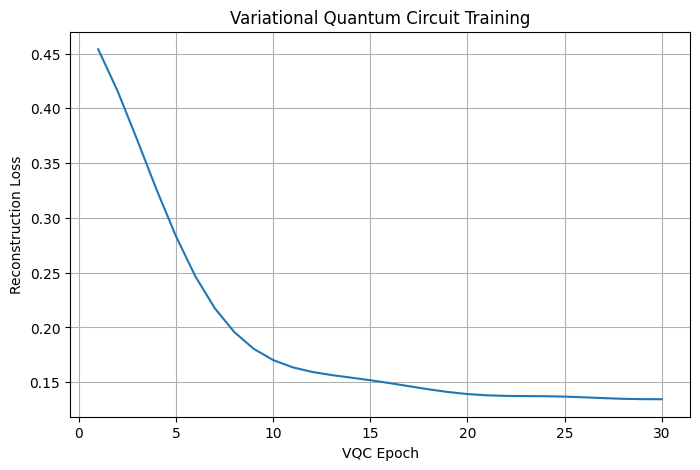


Quantum representation:
Train: (47, 4)
Test : (16, 4)

Temporal representation: (63, 16)


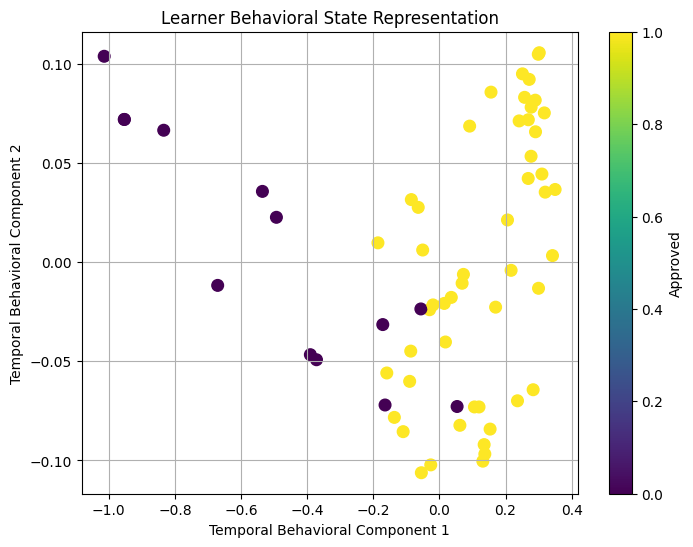


Saved: /content/drive/MyDrive/Web mining files/Quantum_Behavioral_Feature_Extraction.xlsx

PROCESS 2 COMPLETED.


In [ ]:
# ================================================================
# PROCESS 2
# QUANTUM-ENHANCED FEATURE EXTRACTION
# ================================================================

!pip -q install pennylane

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml

print("=" * 70)
print("PROCESS 2 - FEATURE EXTRACTION")
print("=" * 70)


# ================================================================
# 1. TRAIN / TEST SPLIT
# ================================================================

X_train_b, X_test_b, y_train, y_test = (
    train_test_split(
        X_behavior,
        y,
        test_size=0.25,
        stratify=y,
        random_state=SEED
    )
)


# ================================================================
# 2. STANDARDIZATION
# ================================================================

behavior_scaler = StandardScaler()

X_train_scaled = (
    behavior_scaler.fit_transform(
        X_train_b
    )
)

X_test_scaled = (
    behavior_scaler.transform(
        X_test_b
    )
)


print(
    "Training samples:",
    len(X_train_b)
)

print(
    "Testing samples:",
    len(X_test_b)
)


# ================================================================
# 3. PCA FOR QUANTUM INPUT
# ================================================================

N_QUBITS = 4
N_VQC_LAYERS = 2

pca_quantum = PCA(
    n_components=N_QUBITS,
    random_state=SEED
)

X_train_pca = (
    pca_quantum.fit_transform(
        X_train_scaled
    )
)

X_test_pca = (
    pca_quantum.transform(
        X_test_scaled
    )
)


print(
    "\nPCA representation:",
    X_train_pca.shape
)


# ================================================================
# 4. QUANTUM ANGLE ENCODING
# ================================================================

train_min = X_train_pca.min(
    axis=0,
    keepdims=True
)

train_max = X_train_pca.max(
    axis=0,
    keepdims=True
)

train_range = (
    train_max - train_min
)

train_range[
    train_range == 0
] = 1


X_train_angles = (
    (X_train_pca - train_min)
    / train_range
) * 2 * np.pi - np.pi


X_test_angles = (
    (X_test_pca - train_min)
    / train_range
) * 2 * np.pi - np.pi


# ================================================================
# 5. QUANTUM DEVICE
# ================================================================

dev = qml.device(
    "default.qubit",
    wires=N_QUBITS
)


# ================================================================
# 6. VARIATIONAL QUANTUM CIRCUIT
# ================================================================

def quantum_circuit(
    inputs,
    weights
):

    # Quantum Feature Encoding

    for q in range(N_QUBITS):

        qml.RY(
            inputs[q],
            wires=q
        )

        qml.RZ(
            inputs[q],
            wires=q
        )


    # Variational layers

    for layer in range(
        N_VQC_LAYERS
    ):

        for q in range(N_QUBITS):

            qml.RY(
                weights[layer, q, 0],
                wires=q
            )

            qml.RZ(
                weights[layer, q, 1],
                wires=q
            )


        # Entanglement

        for q in range(
            N_QUBITS - 1
        ):

            qml.CNOT(
                wires=[q, q + 1]
            )


        qml.CNOT(
            wires=[
                N_QUBITS - 1,
                0
            ]
        )


    return [
        qml.expval(
            qml.PauliZ(q)
        )
        for q in range(N_QUBITS)
    ]


qnode = qml.QNode(
    quantum_circuit,
    dev,
    interface="torch"
)


# ================================================================
# 7. TRAIN VQC
# ================================================================

X_quantum_train = torch.tensor(
    X_train_angles,
    dtype=torch.float32
)


target_train = torch.tensor(
    X_train_pca,
    dtype=torch.float32
)


target_min = (
    target_train.min(
        dim=0,
        keepdim=True
    ).values
)

target_max = (
    target_train.max(
        dim=0,
        keepdim=True
    ).values
)

target_range = (
    target_max - target_min
)

target_range[
    target_range == 0
] = 1


target_train_norm = (
    2
    * (
        target_train
        - target_min
    )
    / target_range
    - 1
)


# Trainable weights

vqc_weights = torch.tensor(
    0.01 * np.random.randn(
        N_VQC_LAYERS,
        N_QUBITS,
        2
    ),
    dtype=torch.float32,
    requires_grad=True
)


optimizer = optim.Adam(
    [vqc_weights],
    lr=0.08
)


VQC_EPOCHS = 30

loss_history = []


for epoch in range(
    VQC_EPOCHS
):

    optimizer.zero_grad()

    predictions = []

    for sample in X_quantum_train:

        quantum_output = qnode(
            sample,
            vqc_weights
        )

        predictions.append(
            torch.stack(
                quantum_output
            )
        )


    predictions = torch.stack(
        predictions
    )


    loss = torch.mean(
        (
            predictions
            - target_train_norm
        ) ** 2
    )


    loss.backward()

    optimizer.step()

    loss_history.append(
        float(
            loss.detach()
        )
    )


    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
    ):

        print(
            f"Epoch "
            f"{epoch + 1:02d}/"
            f"{VQC_EPOCHS}"
            f" - Loss: "
            f"{loss.item():.6f}"
        )


# ================================================================
# 8. LOSS VISUALIZATION
# ================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(loss_history) + 1
    ),
    loss_history
)

plt.xlabel("VQC Epoch")
plt.ylabel("Reconstruction Loss")

plt.title(
    "Variational Quantum Circuit Training"
)

plt.grid(True)

plt.show()


# ================================================================
# 9. QUANTUM REPRESENTATION GENERATION
# ================================================================

def generate_quantum_representation(
    X_angles
):

    representations = []

    for sample in X_angles:

        output = qnode(
            torch.tensor(
                sample,
                dtype=torch.float32
            ),
            vqc_weights.detach()
        )

        output = torch.stack(
            output
        ).detach().numpy()

        representations.append(
            output
        )

    return np.asarray(
        representations
    )


Q_train = (
    generate_quantum_representation(
        X_train_angles
    )
)

Q_test = (
    generate_quantum_representation(
        X_test_angles
    )
)


# ================================================================
# 10. DESCRIPTIVE QUANTUM FEATURE NAMES
# ================================================================

quantum_feature_names = [

    "Quantum_Behavioral_Interaction_State",

    "Quantum_Behavioral_Engagement_State",

    "Quantum_Behavioral_Time_State",

    "Quantum_Behavioral_Skill_State"
]


Q_train_df = pd.DataFrame(
    Q_train,
    columns=quantum_feature_names
)

Q_test_df = pd.DataFrame(
    Q_test,
    columns=quantum_feature_names
)


print("\nQuantum representation:")
print(
    "Train:",
    Q_train.shape
)

print(
    "Test :",
    Q_test.shape
)


# ================================================================
# 11. TEMPORAL BEHAVIORAL STATE EXTRACTION
# ================================================================

interaction_state_features = [
    "Total_Interaction_Count",
    "Average_Post_Activity",
    "Positive_Engagement_Count",
    "Positive_Engagement_Rate"
]


help_state_features = [
    "Helpful_Post_Rate",
    "Confusion_Post_Rate",
    "Help_Seeking_Negative_Count",
    "Help_Seeking_Negative_Rate"
]


creative_state_features = [
    "Creative_Post_Rate",
    "Nice_Code_Post_Rate",
    "Collaborative_Post_Rate",
    "Amazing_Post_Rate"
]


time_state_features = [
    "Time_Online_Minutes",
    "Time_Per_Post",
    "Interaction_Density"
]


skill_state_features = [
    "Classroom_Skill_Mean",
    "Classroom_Skill_Std",
    "Classroom_Skill_Max",
    "Classroom_Skill_Min",
    "Classroom_Skill_Range"
]


state_groups = [
    interaction_state_features,
    help_state_features,
    creative_state_features,
    time_state_features,
    skill_state_features
]


state_vectors = []

for group in state_groups:

    available = [
        f
        for f in group
        if f in df.columns
    ]

    state_vectors.append(
        df[available].mean(
            axis=1
        ).values
    )


state_matrix = np.column_stack(
    state_vectors
)


# ================================================================
# 12. TEMPORAL REPRESENTATION
# ================================================================

temporal_scaler = StandardScaler()

temporal_states = (
    temporal_scaler.fit_transform(
        state_matrix
    )
)


class BehavioralTemporalEncoder(
    nn.Module
):

    def __init__(
        self,
        input_size=1,
        hidden_size=16
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )


    def forward(self, x):

        output, hidden = self.gru(x)

        return hidden[-1]


temporal_model = (
    BehavioralTemporalEncoder(
        input_size=1,
        hidden_size=16
    )
)


temporal_input = torch.tensor(
    state_matrix,
    dtype=torch.float32
).unsqueeze(-1)


with torch.no_grad():

    temporal_representation = (
        temporal_model(
            temporal_input
        )
        .numpy()
    )


print(
    "\nTemporal representation:",
    temporal_representation.shape
)


# ================================================================
# 13. TEMPORAL VISUALIZATION
# ================================================================

temporal_pca = PCA(
    n_components=2,
    random_state=SEED
)

temporal_2d = (
    temporal_pca.fit_transform(
        temporal_representation
    )
)


plt.figure(figsize=(8, 6))

plt.scatter(
    temporal_2d[:, 0],
    temporal_2d[:, 1],
    c=y,
    cmap="viridis",
    s=70
)

plt.xlabel(
    "Temporal Behavioral Component 1"
)

plt.ylabel(
    "Temporal Behavioral Component 2"
)

plt.title(
    "Learner Behavioral State Representation"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.show()


# ================================================================
# 14. SAVE EXTRACTION OUTPUT
# ================================================================

EXTRACTION_FILE = (
    "/content/drive/MyDrive/Web mining files/"
    "Quantum_Behavioral_Feature_Extraction.xlsx"
)


with pd.ExcelWriter(
    EXTRACTION_FILE,
    engine="openpyxl"
) as writer:

    Q_train_df.to_excel(
        writer,
        sheet_name="Quantum_Train",
        index=False
    )

    Q_test_df.to_excel(
        writer,
        sheet_name="Quantum_Test",
        index=False
    )

    pd.DataFrame(
        temporal_representation
    ).to_excel(
        writer,
        sheet_name="Temporal_Representation",
        index=False
    )


print(
    "\nSaved:",
    EXTRACTION_FILE
)

print("\nPROCESS 2 COMPLETED.")

PROCESS 2 - FEATURE EXTRACTION RESULTS


,Representation,Dimensions
0,Original Behavioral Features,21
1,Standardized Behavioral Features,21
2,PCA Quantum Input,4
3,Quantum Representation,4
4,Temporal Representation,16


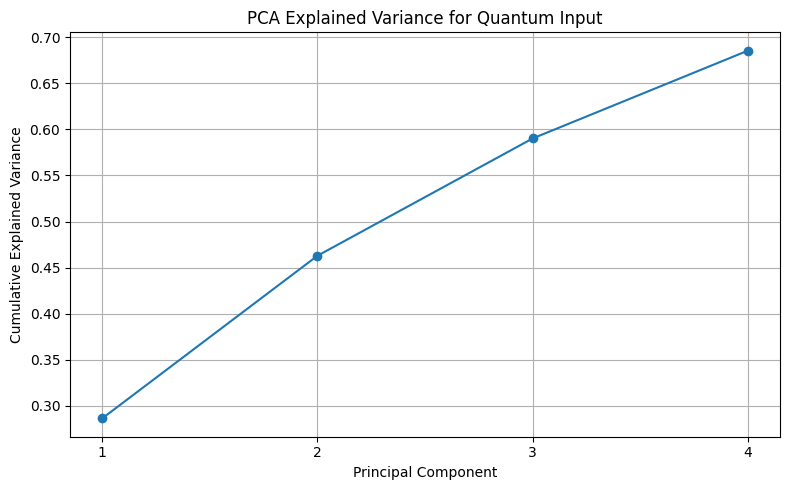

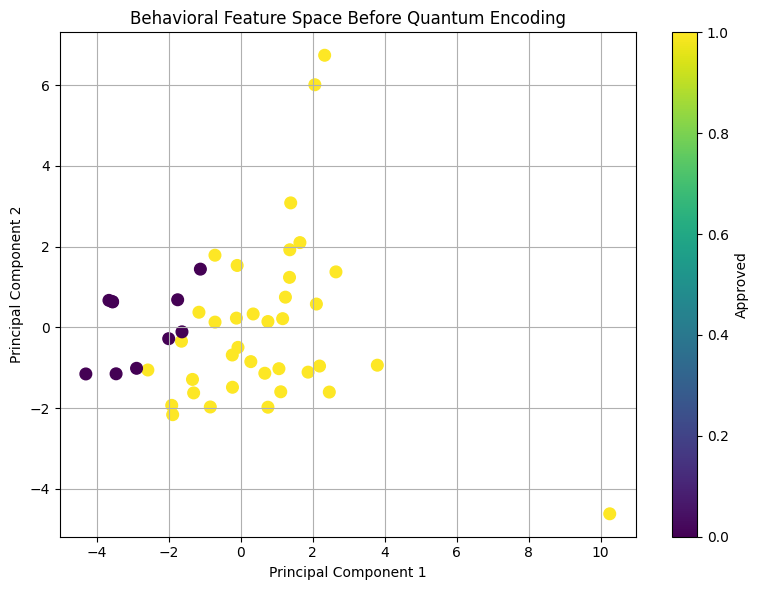

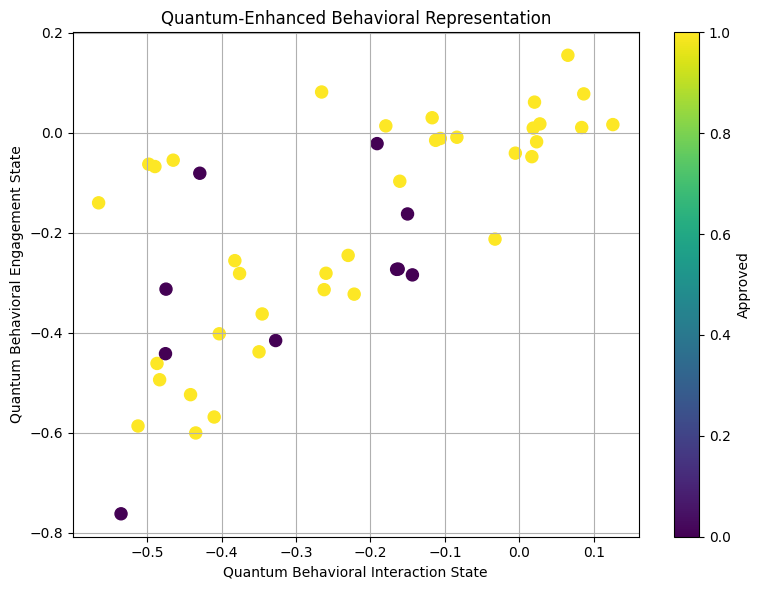

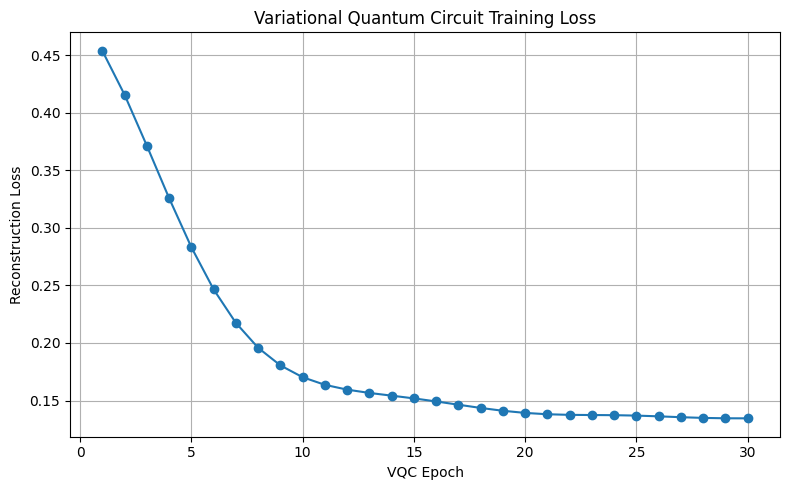

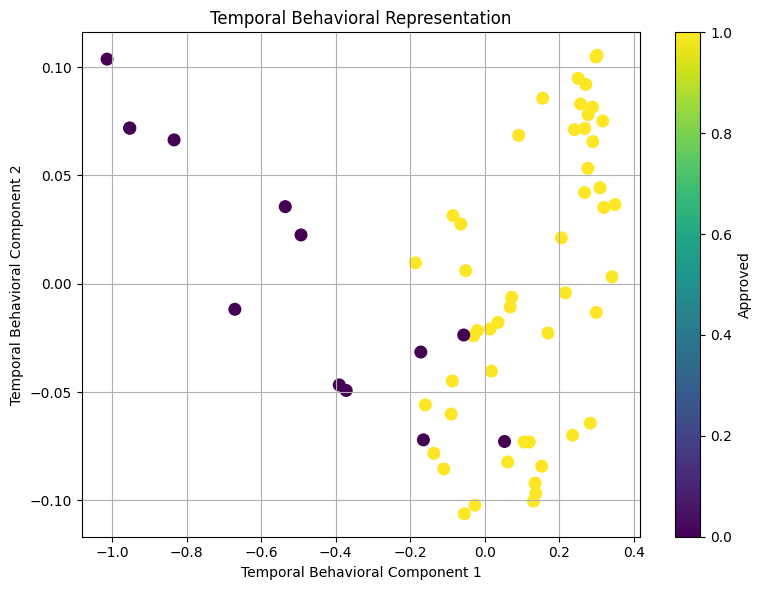

,count,mean,std,min,25%,50%,75%,max
Quantum_Behavioral_Interaction_State,47.0,-0.239709,0.203776,-0.565132,-0.431960,-0.229999,-0.095061,0.125552
Quantum_Behavioral_Engagement_State,47.0,-0.201666,0.221929,-0.762327,-0.342790,-0.162595,-0.013471,0.154828
Quantum_Behavioral_Time_State,47.0,0.096724,0.282285,-0.327353,-0.093088,0.025232,0.269271,0.795512
Quantum_Behavioral_Skill_State,47.0,-0.316516,0.187737,-0.689429,-0.456649,-0.314350,-0.231787,0.206106


,count,mean,std,min,25%,50%,75%,max
0,63.0,0.195386,0.082566,0.113582,0.132201,0.174153,0.215110,0.455039
1,63.0,-0.893267,0.076721,-0.953857,-0.945830,-0.915881,-0.884607,-0.620165
2,63.0,0.429387,0.056282,0.247253,0.419064,0.438178,0.454684,0.530053
3,63.0,-0.513564,0.131650,-0.673900,-0.638013,-0.524612,-0.447558,-0.186297
4,63.0,-0.257987,0.036958,-0.383237,-0.263448,-0.244483,-0.232960,-0.224181
5,63.0,-0.151047,0.123151,-0.303518,-0.238550,-0.182936,-0.108562,0.178081
6,63.0,0.561791,0.123687,0.189177,0.525602,0.590270,0.665550,0.689786
7,63.0,-0.839038,0.046563,-0.887850,-0.877357,-0.845960,-0.823204,-0.690684
8,63.0,0.833125,0.097948,0.523048,0.815810,0.860582,0.905086,0.921680
9,63.0,-0.437366,0.059927,-0.521564,-0.499685,-0.432279,-0.399216,-0.312279



PROCESS 2 RESULT COMPLETED.


In [ ]:
# ================================================================
# PROCESS 2 - RESULTS AND VISUALIZATIONS
# QUANTUM + TEMPORAL FEATURE EXTRACTION
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

print("=" * 70)
print("PROCESS 2 - FEATURE EXTRACTION RESULTS")
print("=" * 70)


# ================================================================
# RESULT 1 - DIMENSION REDUCTION
# ================================================================

extraction_results = pd.DataFrame({

    "Representation": [

        "Original Behavioral Features",
        "Standardized Behavioral Features",
        "PCA Quantum Input",
        "Quantum Representation",
        "Temporal Representation"
    ],

    "Dimensions": [

        X_behavior.shape[1],
        X_train_scaled.shape[1],
        X_train_pca.shape[1],
        Q_train.shape[1],
        temporal_representation.shape[1]
    ]
})


display(
    extraction_results
)


# ================================================================
# VISUALIZATION 1
# PCA EXPLAINED VARIANCE
# ================================================================

explained_variance = (
    pca_quantum.explained_variance_ratio_
)


cumulative_variance = (
    np.cumsum(
        explained_variance
    )
)


plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(explained_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance for Quantum Input"
)

plt.xticks(
    range(
        1,
        len(explained_variance) + 1
    )
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 2
# PCA 2D REPRESENTATION
# ================================================================

pca_visual = PCA(
    n_components=2,
    random_state=SEED
)

pca_2d = (
    pca_visual.fit_transform(
        X_train_scaled
    )
)


plt.figure(figsize=(8, 6))

plt.scatter(
    pca_2d[:, 0],
    pca_2d[:, 1],
    c=y_train,
    cmap="viridis",
    s=70
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Behavioral Feature Space Before Quantum Encoding"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 3
# QUANTUM REPRESENTATION
# ================================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    Q_train[:, 0],
    Q_train[:, 1],
    c=y_train,
    cmap="viridis",
    s=75
)

plt.xlabel(
    "Quantum Behavioral Interaction State"
)

plt.ylabel(
    "Quantum Behavioral Engagement State"
)

plt.title(
    "Quantum-Enhanced Behavioral Representation"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 4
# VQC TRAINING LOSS
# ================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(loss_history) + 1
    ),
    loss_history,
    marker="o"
)

plt.xlabel(
    "VQC Epoch"
)

plt.ylabel(
    "Reconstruction Loss"
)

plt.title(
    "Variational Quantum Circuit Training Loss"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 5
# TEMPORAL REPRESENTATION
# ================================================================

temporal_visual_pca = PCA(
    n_components=2,
    random_state=SEED
)

temporal_visual = (
    temporal_visual_pca.fit_transform(
        temporal_representation
    )
)


plt.figure(figsize=(8, 6))

plt.scatter(
    temporal_visual[:, 0],
    temporal_visual[:, 1],
    c=y,
    cmap="viridis",
    s=70
)

plt.xlabel(
    "Temporal Behavioral Component 1"
)

plt.ylabel(
    "Temporal Behavioral Component 2"
)

plt.title(
    "Temporal Behavioral Representation"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# RESULT 2 - QUANTUM FEATURE STATISTICS
# ================================================================

quantum_statistics = (
    Q_train_df.describe()
    .T
)

display(
    quantum_statistics
)


# ================================================================
# RESULT 3 - TEMPORAL FEATURE STATISTICS
# ================================================================

temporal_statistics = (
    pd.DataFrame(
        temporal_representation
    ).describe().T
)

display(
    temporal_statistics
)


print("\nPROCESS 2 RESULT COMPLETED.")

PROCESS 3 - OPTIMIZATION / HYPERGRAPH MODELING

Combined representation: (47, 20)
Number of hyperedges: 47

Hypergraph representation: (47, 20)


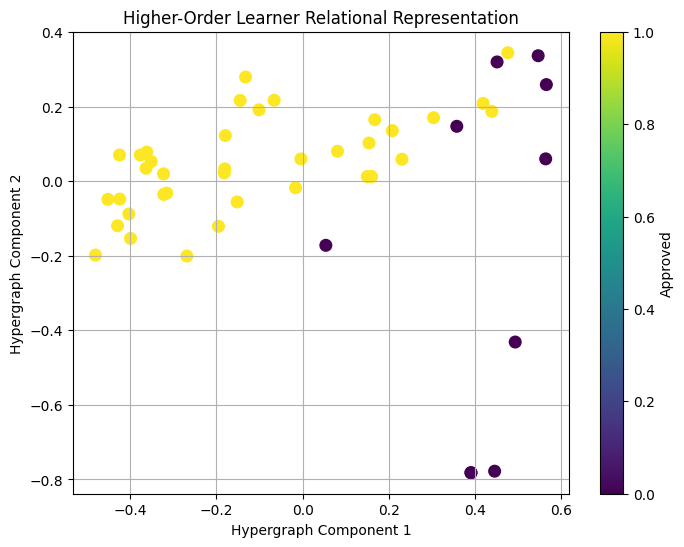


Spectral cluster distribution:
0    27
1    20
Name: count, dtype: int64


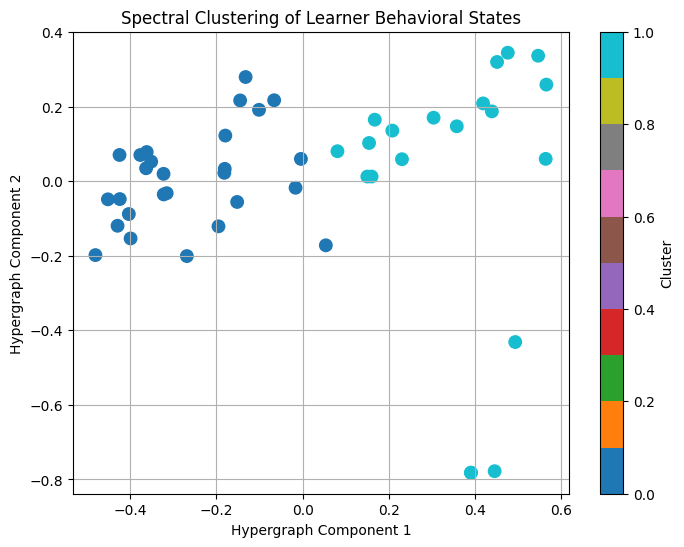

,Optimization_Component,Purpose
0,Learner Similarity,Measure behavioral similarity
1,K-Nearest Neighbor Search,Identify related learners
2,Hyperedge Construction,Construct higher-order learner groups
3,Hypergraph Aggregation,Aggregate relational information
4,Spectral Clustering,Discover learner behavioral groups



Saved: /content/drive/MyDrive/Web mining files/Optimized_Hypergraph_Behavioral_Representation.xlsx

PROCESS 3 COMPLETED.


In [ ]:
# ================================================================
# PROCESS 3
# OPTIMIZATION + HIGHER-ORDER RELATIONAL MODELING
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA

print("=" * 70)
print("PROCESS 3 - OPTIMIZATION / HYPERGRAPH MODELING")
print("=" * 70)


# ================================================================
# 1. ALIGN TRAINING TEMPORAL REPRESENTATION
# ================================================================

train_temporal = (
    temporal_representation[
        X_train_b.index
    ]
)


# ================================================================
# 2. COMBINE QUANTUM + TEMPORAL REPRESENTATIONS
# ================================================================

combined_representation = np.hstack([
    Q_train,
    train_temporal
])


print(
    "\nCombined representation:",
    combined_representation.shape
)


# ================================================================
# 3. LEARNER SIMILARITY
# ================================================================

similarity_matrix = (
    cosine_similarity(
        combined_representation
    )
)

np.fill_diagonal(
    similarity_matrix,
    0
)


# ================================================================
# 4. K-NEAREST LEARNER RELATIONSHIPS
# ================================================================

K_NEIGHBORS = min(
    5,
    len(combined_representation) - 1
)


neighbors_model = (
    NearestNeighbors(
        n_neighbors=K_NEIGHBORS + 1,
        metric="cosine"
    )
)


neighbors_model.fit(
    combined_representation
)


distances, neighbor_indices = (
    neighbors_model.kneighbors(
        combined_representation
    )
)


# ================================================================
# 5. CONSTRUCT HYPEREDGES
# ================================================================

hyperedges = []

for i in range(
    len(combined_representation)
):

    members = neighbor_indices[i]

    hyperedges.append(
        list(members)
    )


print(
    "Number of hyperedges:",
    len(hyperedges)
)


# ================================================================
# 6. HYPERGRAPH AGGREGATION
# ================================================================

hypergraph_representation = (
    combined_representation.copy()
)


for i in range(
    len(combined_representation)
):

    members = hyperedges[i]

    neighbor_mean = (
        combined_representation[
            members
        ].mean(axis=0)
    )


    hypergraph_representation[i] = (

        0.5
        * combined_representation[i]

        +

        0.5
        * neighbor_mean
    )


print(
    "\nHypergraph representation:",
    hypergraph_representation.shape
)


# ================================================================
# 7. HYPERGRAPH VISUALIZATION
# ================================================================

hyper_pca = PCA(
    n_components=2,
    random_state=SEED
)

hyper_2d = (
    hyper_pca.fit_transform(
        hypergraph_representation
    )
)


plt.figure(figsize=(8, 6))

plt.scatter(
    hyper_2d[:, 0],
    hyper_2d[:, 1],
    c=y_train,
    cmap="viridis",
    s=70
)

plt.xlabel(
    "Hypergraph Component 1"
)

plt.ylabel(
    "Hypergraph Component 2"
)

plt.title(
    "Higher-Order Learner Relational Representation"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.show()


# ================================================================
# 8. SPECTRAL CLUSTERING
# ================================================================

spectral_similarity = (
    cosine_similarity(
        hypergraph_representation
    )
)


spectral_similarity = np.maximum(
    spectral_similarity,
    0
)


np.fill_diagonal(
    spectral_similarity,
    1
)


spectral_model = SpectralClustering(
    n_clusters=2,
    affinity="precomputed",
    assign_labels="kmeans",
    random_state=SEED
)


cluster_labels = (
    spectral_model.fit_predict(
        spectral_similarity
    )
)


print(
    "\nSpectral cluster distribution:"
)

print(
    pd.Series(
        cluster_labels
    ).value_counts()
)


# ================================================================
# 9. CLUSTER VISUALIZATION
# ================================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    hyper_2d[:, 0],
    hyper_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=80
)

plt.xlabel(
    "Hypergraph Component 1"
)

plt.ylabel(
    "Hypergraph Component 2"
)

plt.title(
    "Spectral Clustering of Learner Behavioral States"
)

plt.colorbar(
    label="Cluster"
)

plt.grid(True)

plt.show()


# ================================================================
# 10. OPTIMIZATION SUMMARY
# ================================================================

optimization_results = pd.DataFrame({

    "Optimization_Component": [

        "Learner Similarity",
        "K-Nearest Neighbor Search",
        "Hyperedge Construction",
        "Hypergraph Aggregation",
        "Spectral Clustering"
    ],

    "Purpose": [

        "Measure behavioral similarity",
        "Identify related learners",
        "Construct higher-order learner groups",
        "Aggregate relational information",
        "Discover learner behavioral groups"
    ]
})


display(
    optimization_results
)


# ================================================================
# 11. SAVE OPTIMIZATION OUTPUT
# ================================================================

OPTIMIZATION_FILE = (
    "/content/drive/MyDrive/Web mining files/"
    "Optimized_Hypergraph_Behavioral_Representation.xlsx"
)


with pd.ExcelWriter(
    OPTIMIZATION_FILE,
    engine="openpyxl"
) as writer:

    pd.DataFrame(
        hypergraph_representation
    ).to_excel(
        writer,
        sheet_name="Hypergraph_Features",
        index=False
    )

    pd.DataFrame({
        "Spectral_Cluster":
        cluster_labels
    }).to_excel(
        writer,
        sheet_name="Clusters",
        index=False
    )

    optimization_results.to_excel(
        writer,
        sheet_name="Optimization_Summary",
        index=False
    )


print(
    "\nSaved:",
    OPTIMIZATION_FILE
)

print("\nPROCESS 3 COMPLETED.")

PROCESS 3 - OPTIMIZATION RESULTS


,Component,Value
0,Combined Quantum + Temporal Representation,20 dimensions
1,Learner Similarity Matrix,47 x 47
2,Number of Hyperedges,47
3,K Nearest Learners,5
4,Hypergraph Representation,20 dimensions
5,Number of Spectral Clusters,2


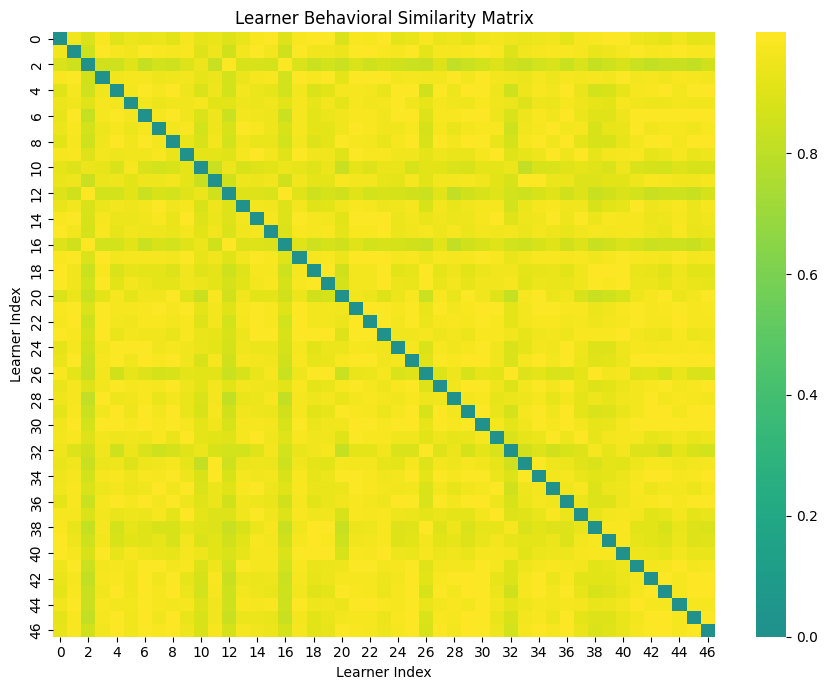

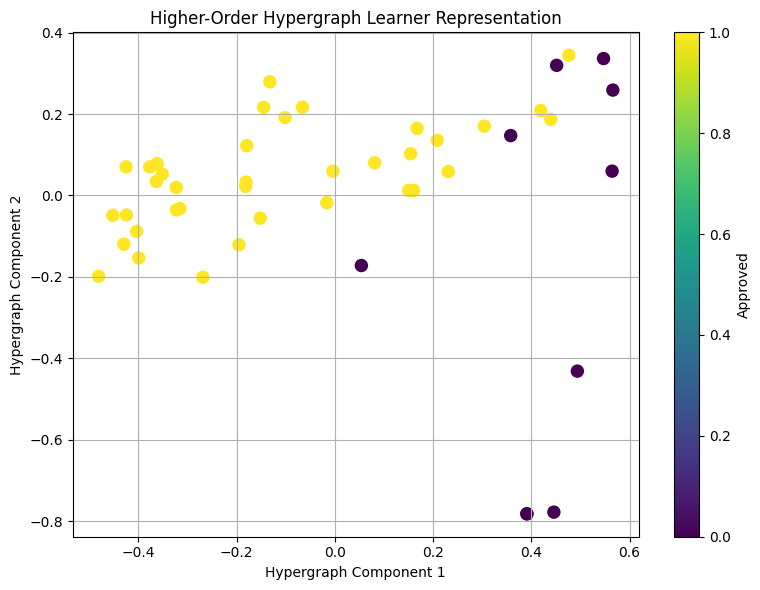

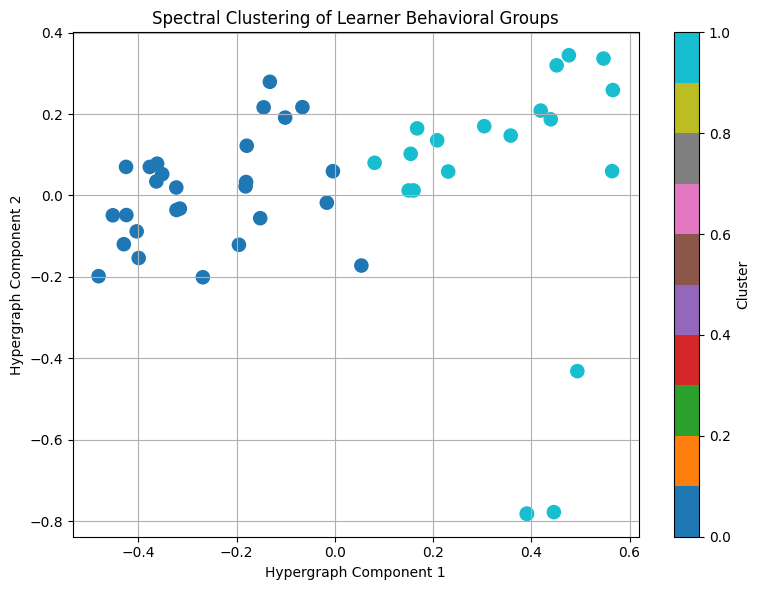

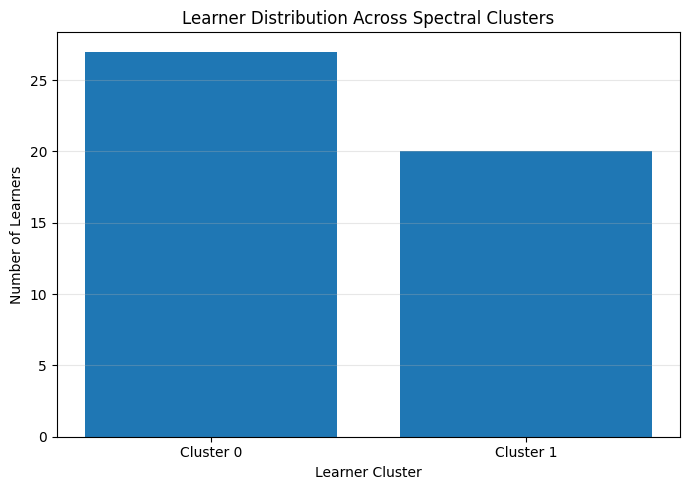

,Cluster,Number_of_Learners
0,0,27
1,1,20


,Hyperedge_ID,Number_of_Members
0,0,6
1,1,6
2,2,6
3,3,6
4,4,6
5,5,6
6,6,6
7,7,6
8,8,6
9,9,6



PROCESS 3 RESULT COMPLETED.


In [ ]:
# ================================================================
# PROCESS 3 - RESULTS AND VISUALIZATIONS
# OPTIMIZATION + HYPERGRAPH MODELING
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

print("=" * 70)
print("PROCESS 3 - OPTIMIZATION RESULTS")
print("=" * 70)


# ================================================================
# RESULT 1
# ================================================================

optimization_results = pd.DataFrame({

    "Component": [

        "Combined Quantum + Temporal Representation",
        "Learner Similarity Matrix",
        "Number of Hyperedges",
        "K Nearest Learners",
        "Hypergraph Representation",
        "Number of Spectral Clusters"
    ],

    "Value": [

        f"{combined_representation.shape[1]} dimensions",

        f"{similarity_matrix.shape[0]} x "
        f"{similarity_matrix.shape[1]}",

        len(hyperedges),

        K_NEIGHBORS,

        f"{hypergraph_representation.shape[1]} dimensions",

        len(np.unique(cluster_labels))
    ]
})


display(
    optimization_results
)


# ================================================================
# VISUALIZATION 1
# LEARNER SIMILARITY MATRIX
# ================================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    similarity_matrix,
    cmap="viridis",
    center=0
)

plt.xlabel(
    "Learner Index"
)

plt.ylabel(
    "Learner Index"
)

plt.title(
    "Learner Behavioral Similarity Matrix"
)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 2
# HYPERGRAPH REPRESENTATION
# ================================================================

hyper_visual_pca = PCA(
    n_components=2,
    random_state=SEED
)

hyper_visual = (
    hyper_visual_pca.fit_transform(
        hypergraph_representation
    )
)


plt.figure(figsize=(8, 6))

plt.scatter(
    hyper_visual[:, 0],
    hyper_visual[:, 1],
    c=y_train,
    cmap="viridis",
    s=75
)

plt.xlabel(
    "Hypergraph Component 1"
)

plt.ylabel(
    "Hypergraph Component 2"
)

plt.title(
    "Higher-Order Hypergraph Learner Representation"
)

plt.colorbar(
    label="Approved"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 3
# SPECTRAL CLUSTERING
# ================================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    hyper_visual[:, 0],
    hyper_visual[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=90
)

plt.xlabel(
    "Hypergraph Component 1"
)

plt.ylabel(
    "Hypergraph Component 2"
)

plt.title(
    "Spectral Clustering of Learner Behavioral Groups"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 4
# CLUSTER DISTRIBUTION
# ================================================================

cluster_counts = (
    pd.Series(
        cluster_labels
    )
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(7, 5))

plt.bar(
    [
        f"Cluster {x}"
        for x in cluster_counts.index
    ],
    cluster_counts.values
)

plt.xlabel(
    "Learner Cluster"
)

plt.ylabel(
    "Number of Learners"
)

plt.title(
    "Learner Distribution Across Spectral Clusters"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# RESULT 2
# CLUSTER TABLE
# ================================================================

cluster_result = pd.DataFrame({

    "Cluster": cluster_counts.index,

    "Number_of_Learners":
        cluster_counts.values
})


display(
    cluster_result
)


# ================================================================
# RESULT 3
# HYPEREDGE INFORMATION
# ================================================================

hyperedge_summary = pd.DataFrame({

    "Hyperedge_ID": range(
        len(hyperedges)
    ),

    "Number_of_Members": [
        len(x)
        for x in hyperedges
    ]
})


display(
    hyperedge_summary.head(10)
)


print("\nPROCESS 3 RESULT COMPLETED.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
PROCESS 4 - PREDICTION

QSVM RESULTS
Accuracy : 0.9167
Precision: 0.9000
Recall   : 1.0000
F1-score : 0.9474
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.90      1.00      0.95         9

    accuracy                           0.92        12
   macro avg       0.95      0.83      0.87        12
weighted avg       0.92      0.92      0.91        12



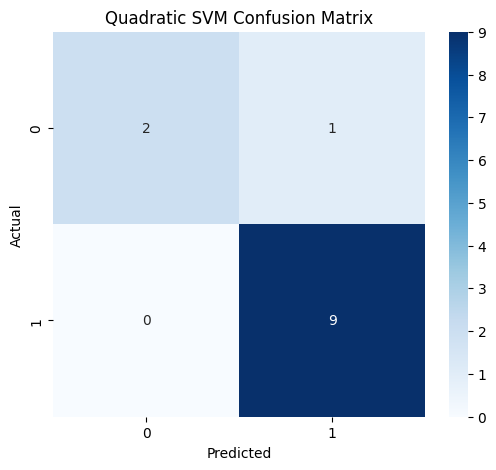

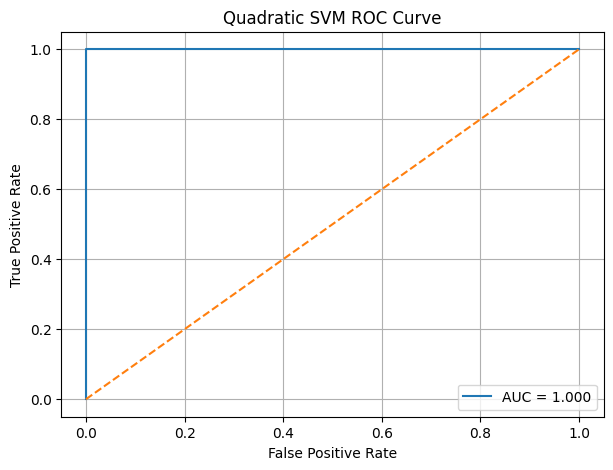

,Metric,Value
0,Number of learners,12.000000
1,Hypergraph features,20.000000
2,Accuracy,0.916667
3,Precision,0.900000
4,Recall,1.000000
5,F1-score,0.947368
6,ROC-AUC,1.000000



Generating SHAP explanation...


  0%|          | 0/10 [00:00<?, ?it/s]

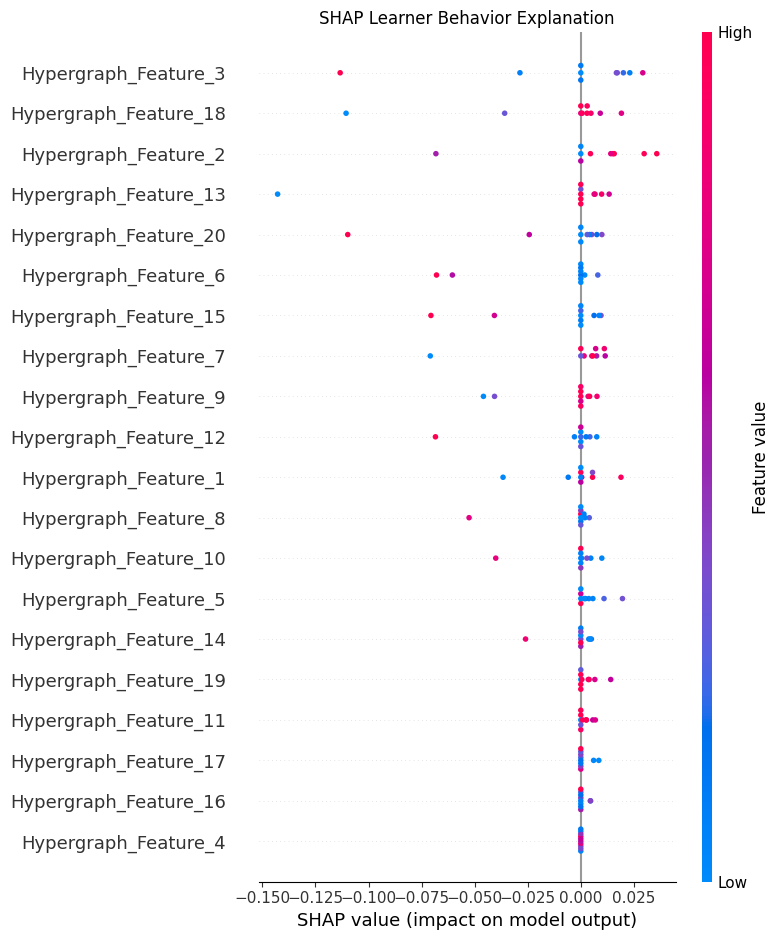


Generating LIME explanation...

LIME explanation:
-0.72 < Hypergraph_Feature_3 <= -0.28: 0.01095
Hypergraph_Feature_7 <= -0.18: -0.00849
Hypergraph_Feature_13 <= -0.21: -0.00732
Hypergraph_Feature_2 <= -0.77: 0.00503
Hypergraph_Feature_20 > 0.19: -0.00503
Hypergraph_Feature_10 > 0.50: -0.00385
-0.16 < Hypergraph_Feature_6 <= 0.13: 0.00226
Hypergraph_Feature_1 <= -1.05: 0.00213
-0.23 < Hypergraph_Feature_9 <= 0.18: 0.00201
-0.10 < Hypergraph_Feature_15 <= 0.29: 0.00157


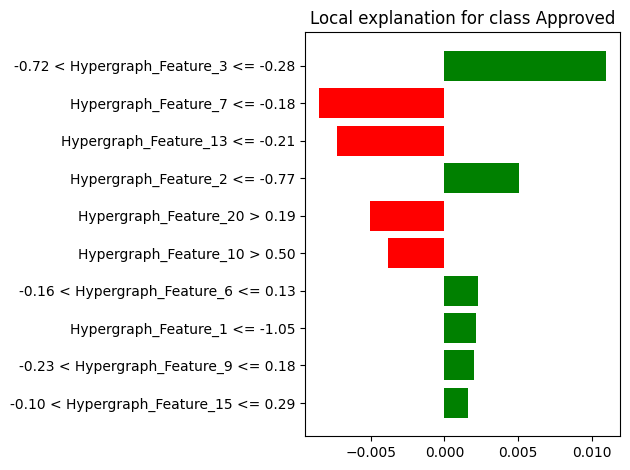


Saved: /content/drive/MyDrive/Web mining files/QSVM_Prediction_Results.xlsx

PROCESS 4 COMPLETED.


COMPLETE PIPELINE FINISHED

PROCESS 1
Preprocessing
      ↓
Behavioral Feature Construction
      ↓

PROCESS 2
Quantum Feature Encoding
      ↓
Variational Quantum Circuit
      ↓
Quantum Representation
      ↓
Temporal Behavioral Representation
      ↓

PROCESS 3
Learner Similarity
      ↓
Hyperedge Construction
      ↓
Hypergraph Aggregation
      ↓
Spectral Clustering
      ↓

PROCESS 4
Quadratic SVM
      ↓
Approved Prediction
      ↓
Accuracy / Precision / Recall / F1 / ROC-AUC
      ↓
Confusion Matrix
      ↓
SHAP + LIME



In [ ]:
# ================================================================
# PROCESS 4
# PREDICTION + EVALUATION + EXPLAINABILITY
# ================================================================

!pip -q install shap lime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("=" * 70)
print("PROCESS 4 - PREDICTION")
print("=" * 70)


# ================================================================
# 1. PREPARE HYPERGRAPH DATA
# ================================================================

X_qsvm = hypergraph_representation

y_hyper = (
    y_train
    .reset_index(drop=True)
)


# ================================================================
# 2. QSVM TRAIN / TEST SPLIT
# ================================================================

X_q_train, X_q_test, y_q_train, y_q_test = (
    train_test_split(
        X_qsvm,
        y_hyper,
        test_size=0.25,
        stratify=y_hyper,
        random_state=SEED
    )
)


# ================================================================
# 3. STANDARDIZATION
# ================================================================

qsvm_scaler = StandardScaler()

X_q_train_scaled = (
    qsvm_scaler.fit_transform(
        X_q_train
    )
)

X_q_test_scaled = (
    qsvm_scaler.transform(
        X_q_test
    )
)


# ================================================================
# 4. QUADRATIC SVM
# ================================================================

qsvm = SVC(

    kernel="poly",

    degree=2,

    C=1.0,

    gamma="scale",

    probability=True,

    random_state=SEED
)


qsvm.fit(
    X_q_train_scaled,
    y_q_train
)


# ================================================================
# 5. PREDICTION
# ================================================================

qsvm_predictions = (
    qsvm.predict(
        X_q_test_scaled
    )
)


qsvm_probabilities = (
    qsvm.predict_proba(
        X_q_test_scaled
    )[:, 1]
)


# ================================================================
# 6. EVALUATION
# ================================================================

accuracy = accuracy_score(
    y_q_test,
    qsvm_predictions
)

precision = precision_score(
    y_q_test,
    qsvm_predictions,
    zero_division=0
)

recall = recall_score(
    y_q_test,
    qsvm_predictions,
    zero_division=0
)

f1 = f1_score(
    y_q_test,
    qsvm_predictions,
    zero_division=0
)


if len(np.unique(y_q_test)) == 2:

    auc = roc_auc_score(
        y_q_test,
        qsvm_probabilities
    )

else:

    auc = np.nan


print("\n" + "=" * 70)
print("QSVM RESULTS")
print("=" * 70)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

print(
    f"ROC-AUC  : {auc:.4f}"
)


print("\nClassification Report:")

print(
    classification_report(
        y_q_test,
        qsvm_predictions,
        zero_division=0
    )
)


# ================================================================
# 7. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_q_test,
    qsvm_predictions
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Quadratic SVM Confusion Matrix"
)

plt.show()


# ================================================================
# 8. ROC CURVE
# ================================================================

if len(np.unique(y_q_test)) == 2:

    fpr, tpr, thresholds = (
        roc_curve(
            y_q_test,
            qsvm_probabilities
        )
    )


    plt.figure(figsize=(7, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {auc:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "Quadratic SVM ROC Curve"
    )

    plt.legend()

    plt.grid(True)

    plt.show()


# ================================================================
# 9. RESULTS TABLE
# ================================================================

prediction_results = pd.DataFrame({

    "Metric": [

        "Number of learners",
        "Hypergraph features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value": [

        len(y_q_test),
        X_q_train_scaled.shape[1],
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})


display(
    prediction_results
)


# ================================================================
# 10. SHAP
# ================================================================

print("\nGenerating SHAP explanation...")


try:

    import shap

    background_size = min(
        15,
        len(X_q_train_scaled)
    )

    background = (
        X_q_train_scaled[
            :background_size
        ]
    )


    def predict_probability(data):

        return qsvm.predict_proba(
            data
        )[:, 1]


    explainer = shap.KernelExplainer(
        predict_probability,
        background
    )


    explain_size = min(
        10,
        len(X_q_test_scaled)
    )


    shap_values = (
        explainer.shap_values(
            X_q_test_scaled[
                :explain_size
            ],
            nsamples=100
        )
    )


    if isinstance(
        shap_values,
        list
    ):

        shap_array = shap_values[0]

    else:

        shap_array = shap_values


    plt.figure()

    shap.summary_plot(

        shap_array,

        X_q_test_scaled[
            :explain_size
        ],

        feature_names=[
            f"Hypergraph_Feature_{i+1}"
            for i in range(
                X_q_train_scaled.shape[1]
            )
        ],

        show=False
    )

    plt.title(
        "SHAP Learner Behavior Explanation"
    )

    plt.tight_layout()

    plt.show()


except Exception as e:

    print(
        "SHAP error:",
        e
    )


# ================================================================
# 11. LIME
# ================================================================

print(
    "\nGenerating LIME explanation..."
)


try:

    from lime.lime_tabular import (
        LimeTabularExplainer
    )


    feature_names = [
        f"Hypergraph_Feature_{i+1}"
        for i in range(
            X_q_train_scaled.shape[1]
        )
    ]


    lime_explainer = (
        LimeTabularExplainer(

            X_q_train_scaled,

            feature_names=
            feature_names,

            class_names=[
                "Not Approved",
                "Approved"
            ],

            mode="classification",

            random_state=SEED
        )
    )


    if len(X_q_test_scaled) > 0:

        lime_exp = (
            lime_explainer.explain_instance(

                X_q_test_scaled[0],

                qsvm.predict_proba,

                num_features=min(
                    10,
                    X_q_train_scaled.shape[1]
                )
            )
        )


        print(
            "\nLIME explanation:"
        )


        for feature, weight in (
            lime_exp.as_list()
        ):

            print(
                f"{feature}: "
                f"{weight:.5f}"
            )


        lime_fig = (
            lime_exp.as_pyplot_figure()
        )

        plt.tight_layout()

        plt.show()


except Exception as e:

    print(
        "LIME error:",
        e
    )


# ================================================================
# 12. SAVE PREDICTION RESULTS
# ================================================================

prediction_output = pd.DataFrame({

    "Actual_Approved":
        y_q_test.values,

    "Predicted_Approved":
        qsvm_predictions,

    "Approved_Probability":
        qsvm_probabilities
})


PREDICTION_FILE = (
    "/content/drive/MyDrive/Web mining files/"
    "QSVM_Prediction_Results.xlsx"
)


with pd.ExcelWriter(
    PREDICTION_FILE,
    engine="openpyxl"
) as writer:

    prediction_output.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

    prediction_results.to_excel(
        writer,
        sheet_name="Metrics",
        index=False
    )

    pd.DataFrame(
        cm
    ).to_excel(
        writer,
        sheet_name="Confusion_Matrix",
        index=False
    )


print(
    "\nSaved:",
    PREDICTION_FILE
)

print("\nPROCESS 4 COMPLETED.")


# ================================================================
# FINAL PIPELINE
# ================================================================

print("\n")
print("=" * 70)
print("COMPLETE PIPELINE FINISHED")
print("=" * 70)

print("""
PROCESS 1
Preprocessing
      ↓
Behavioral Feature Construction
      ↓

PROCESS 2
Quantum Feature Encoding
      ↓
Variational Quantum Circuit
      ↓
Quantum Representation
      ↓
Temporal Behavioral Representation
      ↓

PROCESS 3
Learner Similarity
      ↓
Hyperedge Construction
      ↓
Hypergraph Aggregation
      ↓
Spectral Clustering
      ↓

PROCESS 4
Quadratic SVM
      ↓
Approved Prediction
      ↓
Accuracy / Precision / Recall / F1 / ROC-AUC
      ↓
Confusion Matrix
      ↓
SHAP + LIME
""")

PROCESS 4 - PREDICTION RESULTS


,Metric,Value
0,Accuracy,0.916667
1,Precision,0.900000
2,Recall,1.000000
3,F1-score,0.947368
4,ROC-AUC,1.000000
5,Average Precision,1.000000


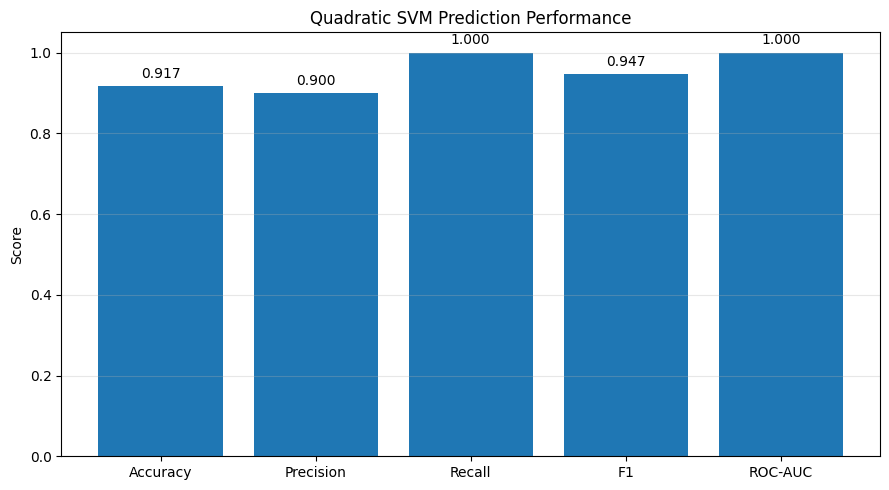

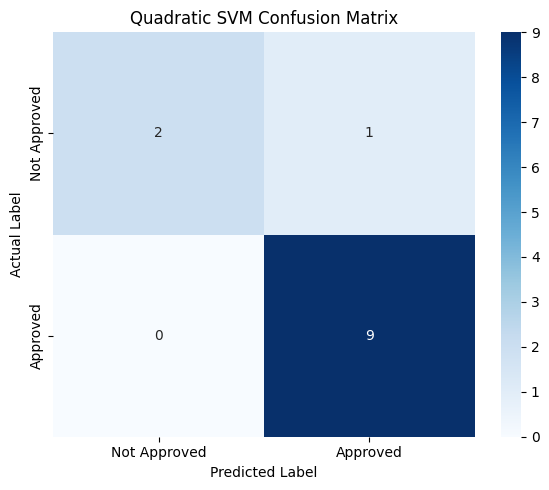

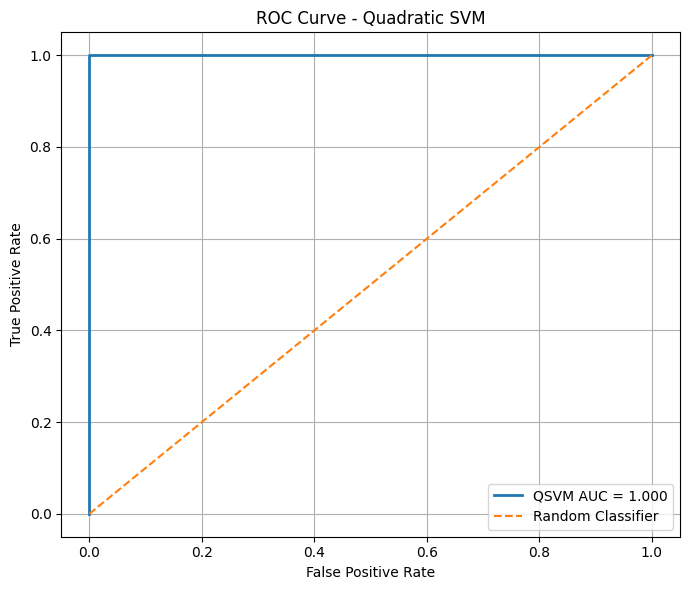

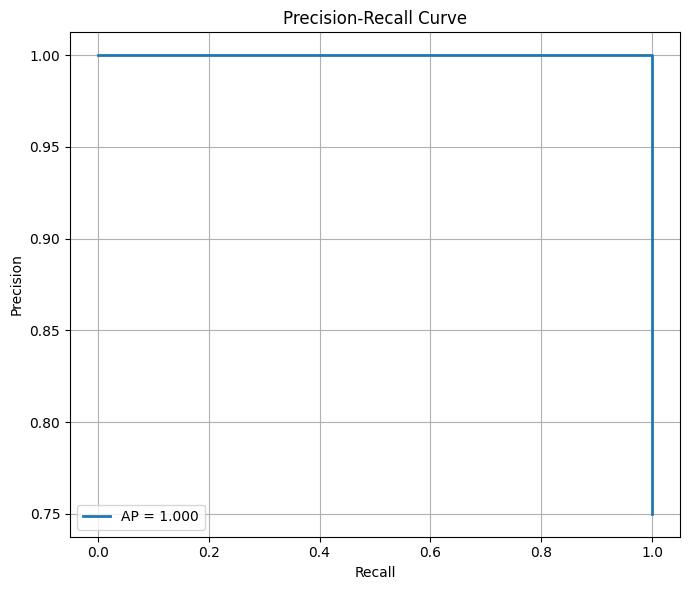

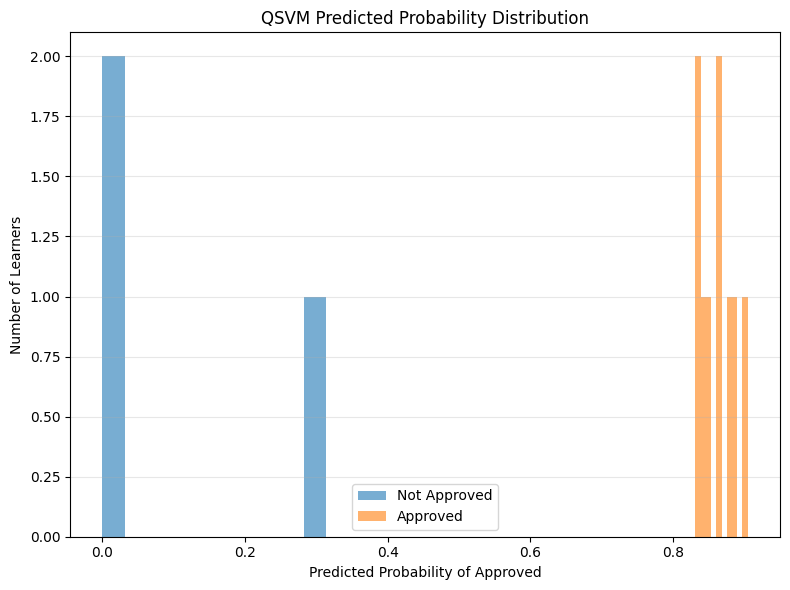

,Actual_Approved,Predicted_Approved,Approved_Probability
0,1,1,0.904259
1,0,1,0.313583
2,1,1,0.885819
3,0,0,0.000271
4,1,1,0.842528
5,1,1,0.849910
6,1,1,0.830928
7,1,1,0.834895
8,1,1,0.864105
9,1,1,0.877230



Classification Report:
              precision    recall  f1-score   support

Not Approved       1.00      0.67      0.80         3
    Approved       0.90      1.00      0.95         9

    accuracy                           0.92        12
   macro avg       0.95      0.83      0.87        12
weighted avg       0.92      0.92      0.91        12


PROCESS 4 RESULT COMPLETED.


In [ ]:
# ================================================================
# PROCESS 4 - RESULTS AND VISUALIZATIONS
# QSVM PREDICTION + EXPLAINABILITY
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

print("=" * 70)
print("PROCESS 4 - PREDICTION RESULTS")
print("=" * 70)


# ================================================================
# 1. PREDICTION
# ================================================================

qsvm_predictions = qsvm.predict(
    X_q_test_scaled
)

qsvm_probabilities = (
    qsvm.predict_proba(
        X_q_test_scaled
    )[:, 1]
)


# ================================================================
# 2. METRICS
# ================================================================

accuracy = accuracy_score(
    y_q_test,
    qsvm_predictions
)

precision = precision_score(
    y_q_test,
    qsvm_predictions,
    zero_division=0
)

recall = recall_score(
    y_q_test,
    qsvm_predictions,
    zero_division=0
)

f1 = f1_score(
    y_q_test,
    qsvm_predictions,
    zero_division=0
)


if len(np.unique(y_q_test)) == 2:

    auc = roc_auc_score(
        y_q_test,
        qsvm_probabilities
    )

    average_precision = (
        average_precision_score(
            y_q_test,
            qsvm_probabilities
        )
    )

else:

    auc = np.nan
    average_precision = np.nan


# ================================================================
# RESULT 1 - METRIC TABLE
# ================================================================

prediction_results = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],

    "Value": [

        accuracy,
        precision,
        recall,
        f1,
        auc,
        average_precision
    ]
})


display(
    prediction_results
)


# ================================================================
# VISUALIZATION 1
# METRIC COMPARISON
# ================================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1,
    auc
]


plt.figure(figsize=(9, 5))

plt.bar(
    metric_names,
    metric_values
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "Quadratic SVM Prediction Performance"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    metric_values
):

    if not np.isnan(value):

        plt.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 2
# CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_q_test,
    qsvm_predictions
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Approved",
        "Approved"
    ],
    yticklabels=[
        "Not Approved",
        "Approved"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Quadratic SVM Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ================================================================
# VISUALIZATION 3
# ROC CURVE
# ================================================================

if len(np.unique(y_q_test)) == 2:

    fpr, tpr, _ = roc_curve(
        y_q_test,
        qsvm_probabilities
    )


    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"QSVM AUC = {auc:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "ROC Curve - Quadratic SVM"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ================================================================
# VISUALIZATION 4
# PRECISION-RECALL CURVE
# ================================================================

if len(np.unique(y_q_test)) == 2:

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_q_test,
            qsvm_probabilities
        )
    )


    plt.figure(figsize=(7, 6))

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"AP = {average_precision:.3f}"
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        "Precision-Recall Curve"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ================================================================
# VISUALIZATION 5
# PREDICTED PROBABILITY DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 6))

plt.hist(
    qsvm_probabilities[
        y_q_test.values == 0
    ],
    bins=10,
    alpha=0.6,
    label="Not Approved"
)

plt.hist(
    qsvm_probabilities[
        y_q_test.values == 1
    ],
    bins=10,
    alpha=0.6,
    label="Approved"
)

plt.xlabel(
    "Predicted Probability of Approved"
)

plt.ylabel(
    "Number of Learners"
)

plt.title(
    "QSVM Predicted Probability Distribution"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# RESULT 2
# PREDICTION TABLE
# ================================================================

prediction_table = pd.DataFrame({

    "Actual_Approved":
        y_q_test.values,

    "Predicted_Approved":
        qsvm_predictions,

    "Approved_Probability":
        qsvm_probabilities
})


display(
    prediction_table
)


# ================================================================
# RESULT 3
# CLASSIFICATION REPORT
# ================================================================

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_q_test,
        qsvm_predictions,
        target_names=[
            "Not Approved",
            "Approved"
        ],
        zero_division=0
    )
)


print("\nPROCESS 4 RESULT COMPLETED.")

EXPLAINABLE LEARNER BEHAVIOR ANALYTICS


  0%|          | 0/10 [00:00<?, ?it/s]

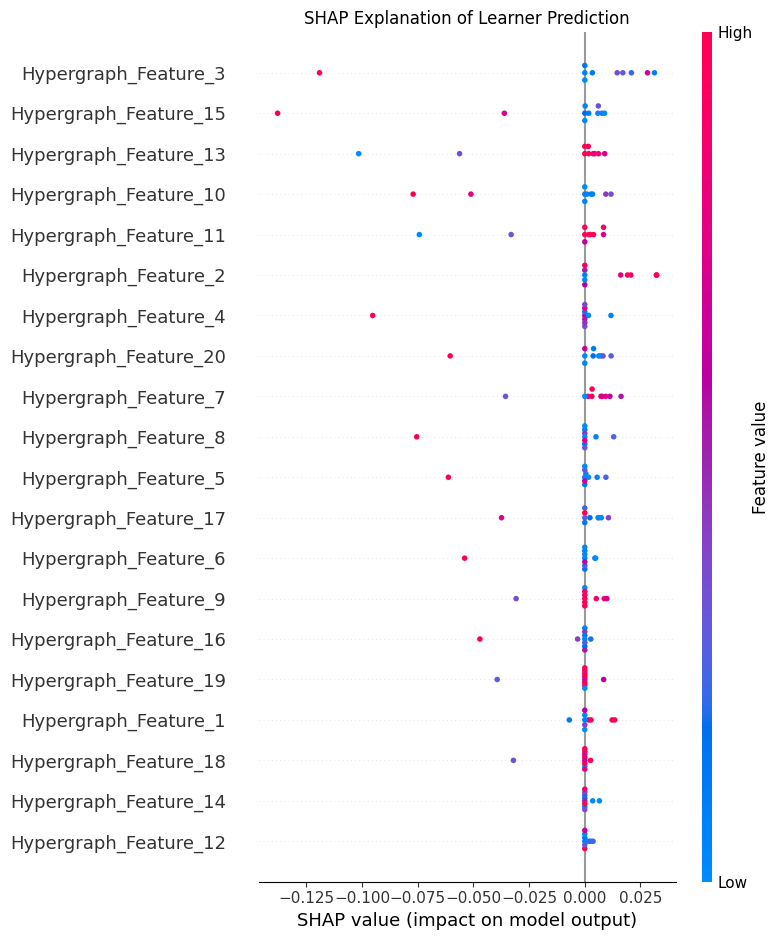


LIME explanation for first test learner:
-0.72 < Hypergraph_Feature_3 <= -0.28: 0.01095
Hypergraph_Feature_7 <= -0.18: -0.00849
Hypergraph_Feature_13 <= -0.21: -0.00732
Hypergraph_Feature_2 <= -0.77: 0.00503
Hypergraph_Feature_20 > 0.19: -0.00503
Hypergraph_Feature_10 > 0.50: -0.00385
-0.16 < Hypergraph_Feature_6 <= 0.13: 0.00226
Hypergraph_Feature_1 <= -1.05: 0.00213
-0.23 < Hypergraph_Feature_9 <= 0.18: 0.00201
-0.10 < Hypergraph_Feature_15 <= 0.29: 0.00157


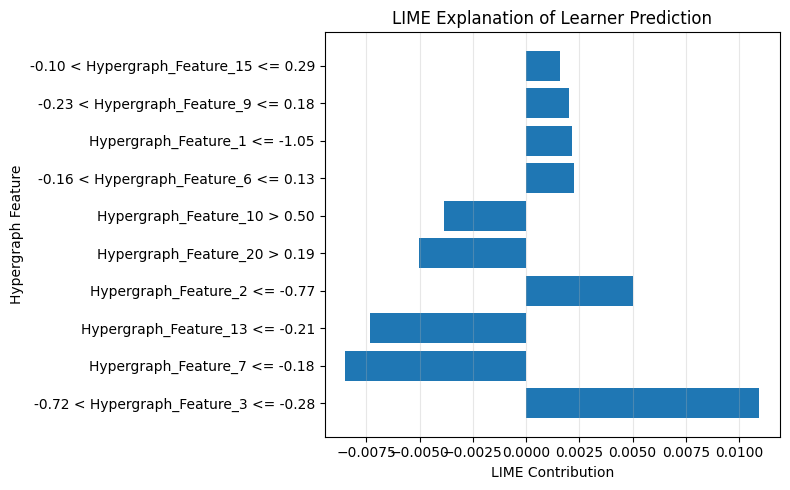


SHAP + LIME analysis completed.


In [ ]:
# ================================================================
# PROCESS 4B
# EXPLAINABLE AI
# SHAP + LIME
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("EXPLAINABLE LEARNER BEHAVIOR ANALYTICS")
print("=" * 70)


# ================================================================
# SHAP
# ================================================================

try:

    import shap

    background_size = min(
        15,
        len(X_q_train_scaled)
    )

    background = (
        X_q_train_scaled[
            :background_size
        ]
    )


    def shap_predict(data):

        return qsvm.predict_proba(
            data
        )[:, 1]


    shap_explainer = (
        shap.KernelExplainer(
            shap_predict,
            background
        )
    )


    explain_size = min(
        10,
        len(X_q_test_scaled)
    )


    shap_values = (
        shap_explainer.shap_values(
            X_q_test_scaled[
                :explain_size
            ],
            nsamples=100
        )
    )


    if isinstance(
        shap_values,
        list
    ):

        shap_array = shap_values[0]

    else:

        shap_array = shap_values


    shap_feature_names = [

        f"Hypergraph_Feature_{i+1}"

        for i in range(
            X_q_train_scaled.shape[1]
        )
    ]


    plt.figure()

    shap.summary_plot(

        shap_array,

        X_q_test_scaled[
            :explain_size
        ],

        feature_names=
        shap_feature_names,

        show=False
    )

    plt.title(
        "SHAP Explanation of Learner Prediction"
    )

    plt.tight_layout()

    plt.show()


except Exception as e:

    print(
        "SHAP error:",
        e
    )


# ================================================================
# LIME
# ================================================================

try:

    from lime.lime_tabular import (
        LimeTabularExplainer
    )


    lime_feature_names = [

        f"Hypergraph_Feature_{i+1}"

        for i in range(
            X_q_train_scaled.shape[1]
        )
    ]


    lime_explainer = (
        LimeTabularExplainer(

            X_q_train_scaled,

            feature_names=
            lime_feature_names,

            class_names=[
                "Not Approved",
                "Approved"
            ],

            mode="classification",

            random_state=SEED
        )
    )


    lime_exp = (
        lime_explainer.explain_instance(

            X_q_test_scaled[0],

            qsvm.predict_proba,

            num_features=min(
                10,
                X_q_train_scaled.shape[1]
            )
        )
    )


    print(
        "\nLIME explanation for first test learner:"
    )


    lime_values = []

    for feature, weight in (
        lime_exp.as_list()
    ):

        print(
            f"{feature}: "
            f"{weight:.5f}"
        )

        lime_values.append(
            (
                feature,
                weight
            )
        )


    plt.figure(
        figsize=(8, 5)
    )

    features = [
        x[0]
        for x in lime_values
    ]

    weights = [
        x[1]
        for x in lime_values
    ]


    plt.barh(
        features,
        weights
    )

    plt.xlabel(
        "LIME Contribution"
    )

    plt.ylabel(
        "Hypergraph Feature"
    )

    plt.title(
        "LIME Explanation of Learner Prediction"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


except Exception as e:

    print(
        "LIME error:",
        e
    )


print(
    "\nSHAP + LIME analysis completed."
)